# Autoreload and import

In [160]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# All auxiliary code is in ../src
import sys
sys.path.append("../../src/")

In [5]:
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import numpy as np
from distribution_utility import stats_on_missing_values

In [8]:
races = pd.read_csv('../../dataset/preprocessedRaces.csv', sep=",")
cyclists = pd.read_csv('../../dataset/preprocessedCyclists.csv', sep=",")
placements = pd.read_csv('../../dataset/preprocessedPlacements.csv', sep=",")

# Introduction

The AgglomerativeClustering algorithm relies on three fundamental input parameters:

- n_clusters: Specifies the number of clusters to find. It defines how many groups the data should be divided into during clustering.

- Distance Metric (metric): Determines the method for calculating the distance between data points. Common options include 'euclidean', 'manhattan', or other distance measures depending on the dataset's nature.

- Linkage Method (linkage): Defines how the proximity between clusters is calculated. The available methods are: ward, complete, average, single

These three parameters together influence how the hierarchical clustering process is performed and how the final clusters are determined

It is possible to provide a graphical representation of the clusters using a dendrogram. By cutting the dendrogram at the appropriate level, we can obtain the desired number of clusters. This approach allows us to visualize how the identified clusters are merged during the hierarchical clustering process, highlighting the hierarchical relationships between them.

# Cyclists

In [7]:
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import numpy as np
from distribution_utility import stats_on_missing_values, show_heatmap


In [ ]:
cyclists = pd.read_csv('../../dataset/preprocessedCyclists.csv', sep=",")

stats_on_missing_values(cyclists)

,Feature,Null_counter,Perc_of_null_(%)
0,name,0,0.0
1,BMI,0,0.0
2,median position,0,0.0
3,AVG position,0,0.0
4,# cyclist races,0,0.0
5,nationality,0,0.0
6,continent,0,0.0
7,geo area,0,0.0
8,birth_year,0,0.0
9,AVG weighted position,0,0.0


## Correlation matrix

To select columns for hierarchical clustering, we first examine the correlation values between columns to exclude highly correlated ones.

In [166]:
display(cyclists.columns)
cyclist_numeric_columns = ['BMI', 'median position', 'AVG position', '# cyclist races', 'birth_year',
       'AVG weighted position', 'AVG position Autumn', 'AVG position Spring',
       'AVG position Summer', 'AVG position Winter', 'AVG position Q1',
       'AVG position Q2', 'AVG position Q3', 'AVG position Q4',
       'std_dev position']

Index(['name', 'BMI', 'median position', 'AVG position', '# cyclist races',
       'nationality', 'continent', 'geo area', 'birth_year',
       'AVG weighted position', 'AVG position Autumn', 'AVG position Spring',
       'AVG position Summer', 'AVG position Winter', 'AVG position Q1',
       'AVG position Q2', 'AVG position Q3', 'AVG position Q4',
       'std_dev position'],
      dtype='object')

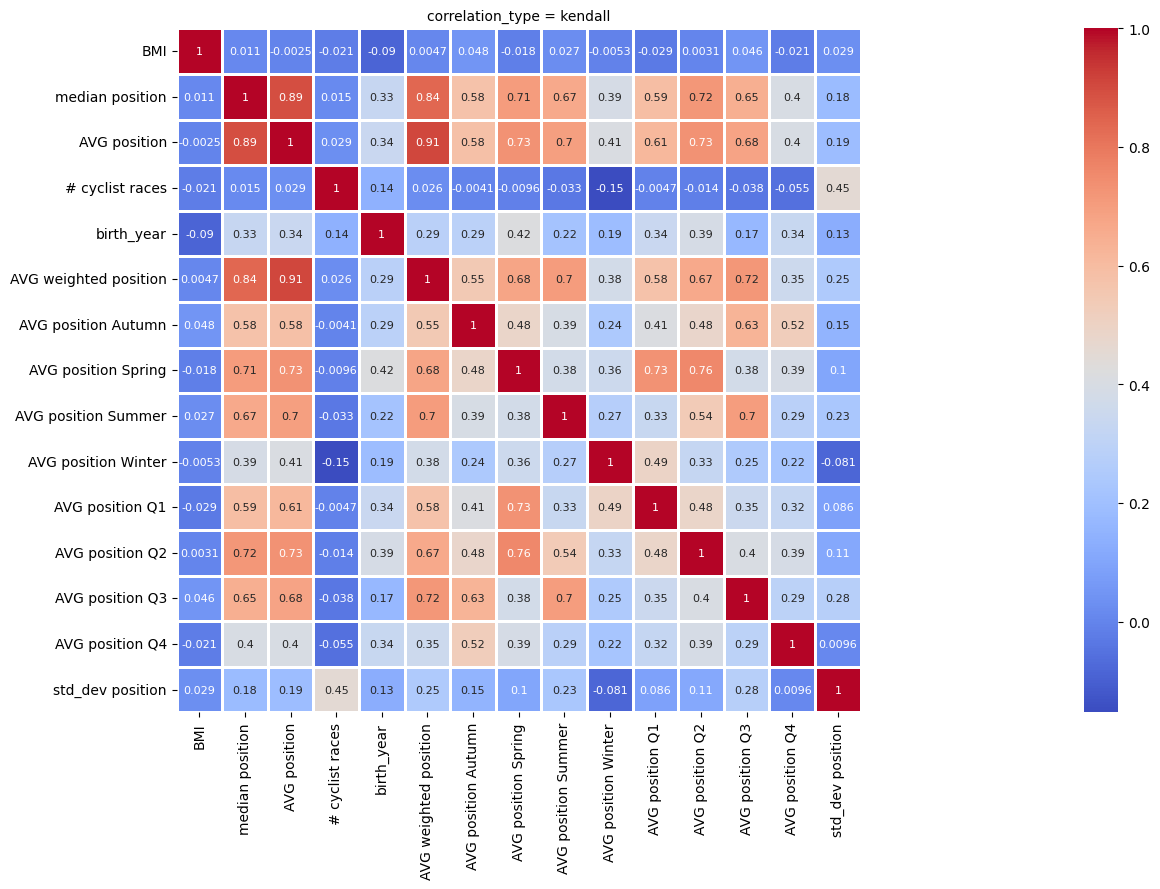

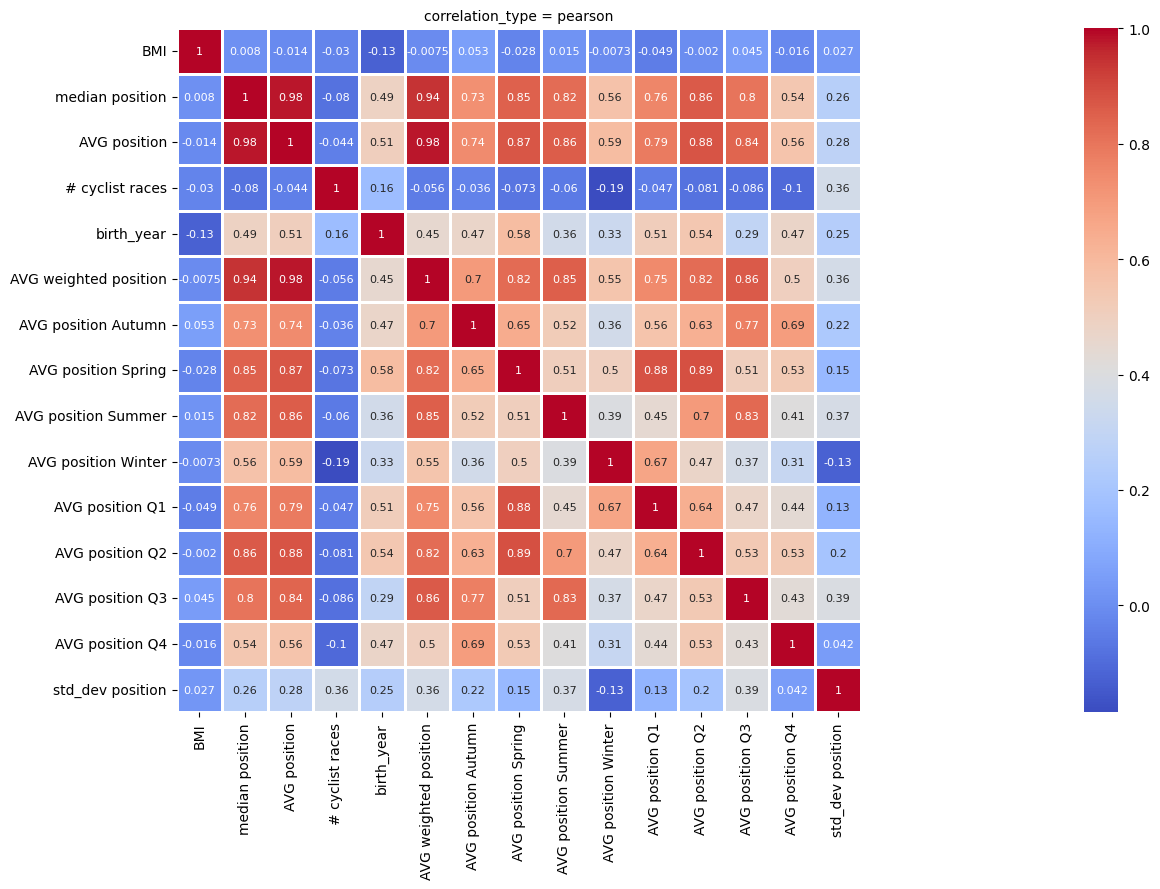

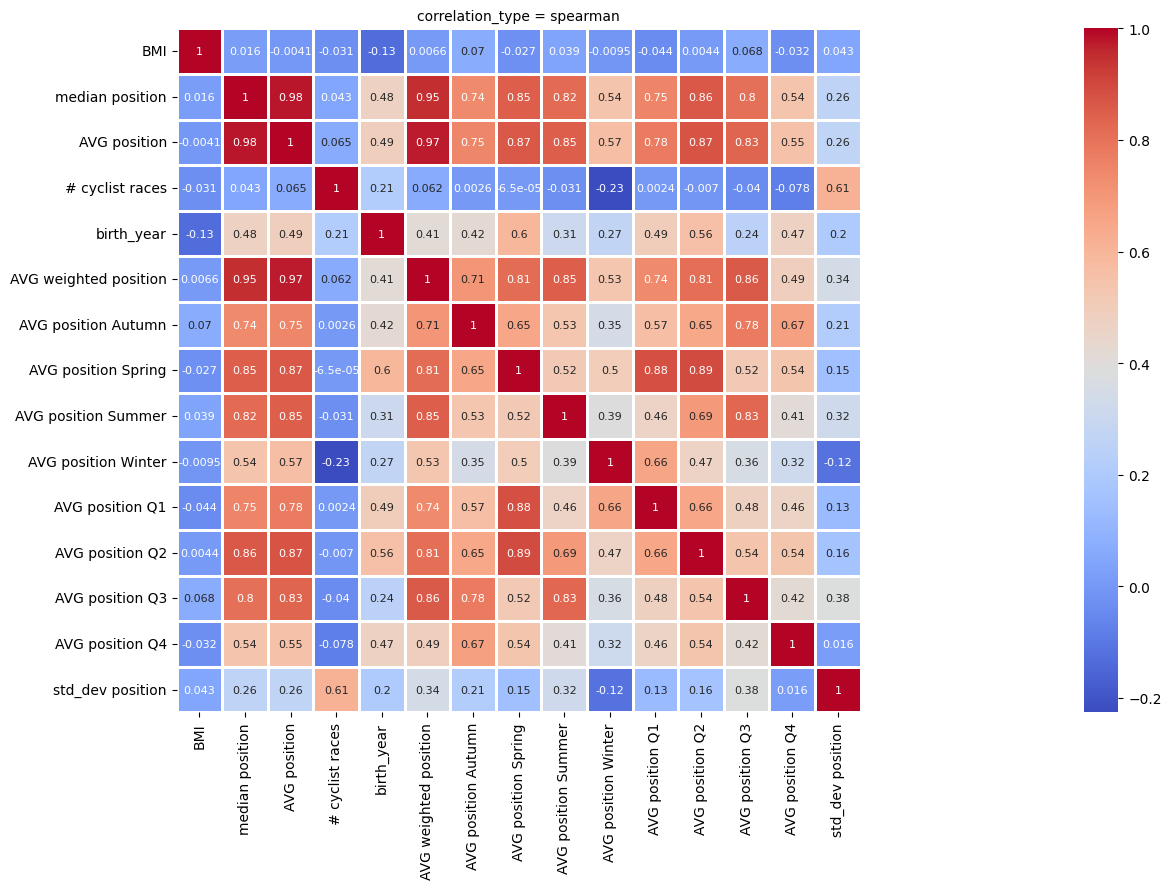

In [167]:
for method in ['kendall', 'pearson', 'spearman']:
    show_heatmap(cyclists, columns = cyclist_numeric_columns, correlation_method = method)

From the correlation matrix, we identified the following columns as having low correlation: BMI, AVG_position, # cyclist races, birth_year, and std_dev_position. We excluded the seasonal and quarterly AVG columns because they are highly correlated with AVG_position and contain a significant number of null values, which are associated with cyclists who did not participate in races during those periods of their careers.

In [168]:
stats_on_missing_values(cyclists)

,Feature,Null_counter,Perc_of_null_(%)
0,name,0,0.0
1,BMI,0,0.0
2,median position,0,0.0
3,AVG position,0,0.0
4,# cyclist races,0,0.0
5,nationality,0,0.0
6,continent,0,0.0
7,geo area,0,0.0
8,birth_year,0,0.0
9,AVG weighted position,0,0.0


## Clustering


### Standardization

In [169]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columns = ['BMI', 'AVG position', '# cyclist races','birth_year', 'std_dev position']
cyclists_working_dataset = cyclists[columns]
# Fit the scaler only once per subset
scaler.fit(cyclists_working_dataset)
std_numeric_cyclists = pd.DataFrame(scaler.transform(cyclists_working_dataset), columns=columns)
display(std_numeric_cyclists)

,BMI,AVG position,# cyclist races,birth_year,std_dev position
0,1.888908,-1.820973,3.780169,-1.159440,-0.480565
1,-1.057115,-0.855506,1.237430,-1.481151,0.791989
2,1.165791,-0.885677,0.349602,-1.288124,-0.019484
3,-0.661193,-1.820973,-0.346455,-1.674178,-0.750644
4,0.066359,-1.308069,0.342499,-1.481151,-0.379919
...,...,...,...,...,...
6090,0.261357,2.915851,-0.680279,-0.322989,-1.866411
6091,0.763178,-1.790803,-0.680279,-0.580358,-1.866411
6092,3.128536,-0.674481,-0.680279,1.156885,-1.866411
6093,-0.918509,-1.157215,-0.680279,-1.674178,-1.866411


### Initial analysis

We will conduct several initial experiments using all the columns and a reasonable number of clusters (5). By varying the linkage method, we will evaluate the clustering performance using the silhouette score.

In [170]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, cophenet, fcluster, dendrogram

def retrieve_clusters_and_score(normalized_dataset, n_clusters, method, metric = 'euclidean'):
    data_dist = pdist(normalized_dataset, metric = metric)  # Compute pairwise distances
    data_link = linkage(data_dist, method=method)  # Perform hierarchical clustering
    clusters = fcluster(data_link, t=n_clusters, criterion='maxclust')
    silh_score = silhouette_score(normalized_dataset, clusters)
    coph_corr, coph_distances = cophenet(data_link, data_dist)
    return {   
        'method': method, 
        'clusters': clusters,
        'clusters_size': np.unique(clusters, return_counts=True)[1],
        'n_cluster': n_clusters,
        'silhouette_score': silh_score,
        'coph_corr': coph_corr,
    }
    
def show_dendogram(normalized_dataset, n_clusters, method, metric = 'euclidean'):
    data_dist = pdist(normalized_dataset, metric=metric)  # Compute pairwise distances
    data_link = linkage(data_dist, method=method)  # Perform hierarchical clustering
    # Plot the dendrogram
    plt.figure(figsize=(10, 7))
    dendrogram(data_link, truncate_mode='lastp', p=n_clusters)
    plt.title(f"Dendrogram (Hierarchical Structure) with {method} method")
    plt.xlabel("Data Points")
    plt.ylabel("Distance")
    plt.show()
    plt.close()

In [171]:
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage

simple_result = []
for method in ['ward', 'complete', 'average', 'single']:
    cluster_score_5 = retrieve_clusters_and_score(std_numeric_cyclists, 5, method, 'euclidean')
    cluster_score_6 = retrieve_clusters_and_score(std_numeric_cyclists, 6, method, 'euclidean')
    cluster_score_7 = retrieve_clusters_and_score(std_numeric_cyclists, 7, method, 'euclidean')
    simple_result.append(cluster_score_5)
    simple_result.append(cluster_score_6)
    simple_result.append(cluster_score_7)
display(pd.DataFrame(simple_result))

,method,clusters,clusters_size,n_cluster,silhouette_score,coph_corr
0,ward,"[1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...]","[1545, 1188, 549, 736, 2077]",5,0.186825,0.478231
1,ward,"[1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...]","[1545, 1188, 549, 736, 790, 1287]",6,0.158848,0.478231
2,ward,"[1, 6, 1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 6, 2, 1, 1, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 1, 2, 2, 1, 3, 1, 1, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 5, 2, 1, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 2, 1, 2, 6, 2, 2, 2, 2, 1, 1, 2, 2, 2, 1, 6, 6, 1, 2, 2, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, ...]","[511, 1034, 1188, 549, 736, 790, 1287]",7,0.139928,0.478231
3,complete,"[2, 5, 2, 4, 4, 4, 2, 4, 4, 2, 2, 4, 5, 4, 2, 2, 4, 4, 4, 2, 2, 2, 2, 4, 4, 4, 4, 2, 4, 4, 4, 4, 2, 2, 4, 4, 2, 2, 2, 2, 4, 4, 4, 4, 4, 2, 2, 4, 4, 2, 2, 4, 4, 4, 4, 2, 2, 2, 2, 4, 4, 2, 2, 4, 2, 2, 2, 4, 2, 4, 5, 4, 4, 4, 4, 2, 4, 4, 4, 4, 4, 5, 5, 2, 2, 4, 5, 2, 2, 4, 5, 4, 2, 4, 4, 4, 2, 5, 4, 4, ...]","[525, 2610, 687, 1037, 1236]",5,0.090756,0.383632
4,complete,"[2, 6, 2, 5, 5, 5, 2, 5, 5, 2, 2, 5, 6, 5, 2, 2, 5, 5, 5, 2, 2, 2, 2, 5, 5, 5, 5, 2, 5, 5, 5, 5, 2, 2, 5, 5, 2, 3, 2, 2, 5, 5, 5, 5, 5, 2, 2, 5, 5, 2, 2, 5, 5, 5, 5, 2, 2, 2, 2, 5, 5, 2, 2, 5, 2, 2, 2, 5, 2, 5, 6, 5, 5, 5, 5, 2, 5, 5, 5, 5, 5, 6, 6, 2, 3, 5, 6, 2, 2, 5, 6, 5, 2, 5, 5, 5, 3, 6, 5, 5, ...]","[525, 557, 2053, 687, 1037, 1236]",6,0.101449,0.383632
5,complete,"[3, 7, 3, 6, 6, 6, 3, 6, 6, 3, 3, 6, 7, 6, 3, 3, 6, 6, 6, 3, 3, 3, 3, 6, 6, 6, 6, 3, 6, 6, 6, 6, 3, 3, 6, 6, 3, 4, 3, 3, 6, 6, 6, 6, 6, 3, 3, 6, 6, 3, 3, 6, 6, 6, 6, 3, 3, 3, 3, 6, 6, 3, 3, 6, 3, 3, 3, 6, 3, 6, 7, 6, 6, 6, 6, 3, 6, 6, 6, 6, 6, 7, 7, 3, 4, 6, 7, 3, 3, 6, 7, 6, 3, 6, 6, 6, 4, 7, 6, 6, ...]","[62, 463, 557, 2053, 687, 1037, 1236]",7,0.083597,0.383632
6,average,"[1, 4, 4, 3, 4, 4, 4, 4, 4, 4, 3, 3, 4, 4, 3, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...]","[4, 44, 924, 5122, 1]",5,0.174975,0.611378
7,average,"[1, 5, 5, 3, 5, 5, 5, 5, 5, 5, 3, 3, 5, 5, 3, 5, 5, 5, 5, 3, 5, 5, 5, 5, 5, 5, 5, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...]","[4, 44, 924, 38, 5084, 1]",6,0.130727,0.611378
8,average,"[1, 6, 6, 3, 6, 6, 6, 6, 6, 6, 3, 3, 6, 6, 3, 6, 6, 6, 6, 3, 6, 6, 6, 6, 6, 6, 6, 3, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 3, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 3, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 3, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...]","[4, 44, 924, 38, 425, 4659, 1]",7,0.120426,0.611378
9,single,"[2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...]","[6091, 1, 1, 1, 1]",5,0.217249,0.376748


The ward and complete methods, while both producing relatively balanced clusters, differ in their silhouette scores, which measure cluster cohesion and separation. The ward method achieves a higher silhouette score (0.1868), indicating better-defined and more cohesive clusters compared to complete (0.0908), which suggests weaker separation between clusters.

On the other hand, the average method has a silhouette score of 0.1750, which, despite being close to ward, is undermined by the highly imbalanced cluster sizes. The single method achieves the highest silhouette score (0.2172), but its extreme imbalance (one dominant cluster and several tiny ones) renders it unsuitable for this dataset, as its behavior is driven by the dense nature of the data and its reliance on minimum distances, similar to density-based clustering

For these simple initial combinations, we will display the dendrogram cut at a level that corresponds to 7 clusters, allowing us to not only visualize the identified clusters at this level but also easily interpret cuts for 6 and 5 clusters. This approach provides flexibility in analyzing the hierarchical relationships and potential cluster groupings across multiple levels. <br>
In this context, we can observe that along the x-axis of the dendrogram, the cluster sizes (in terms of the number of elements) are represented. These sizes correspond to the cluster dimensions identified earlier using the clustering algorithm with cluster_size = 7, providing also a visual confirmation of the cluster distribution

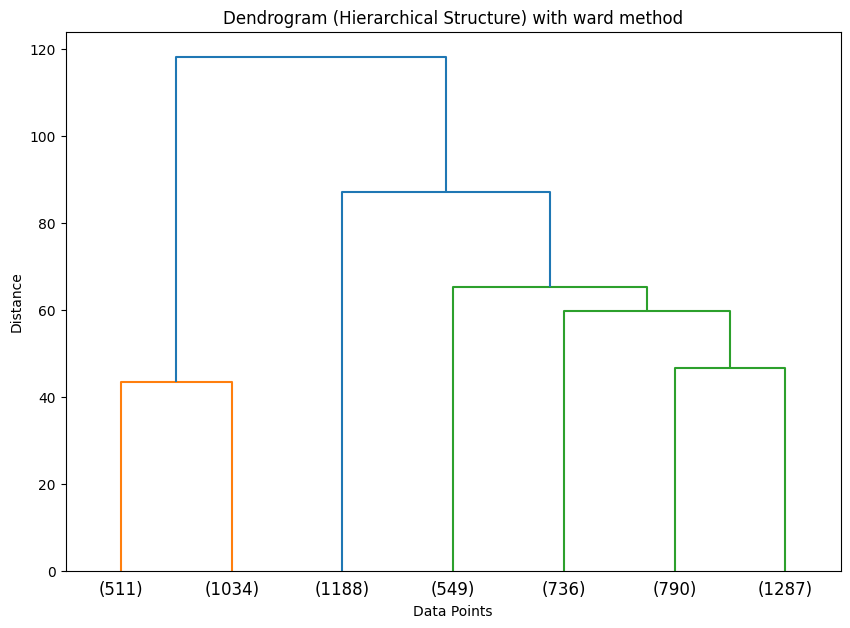

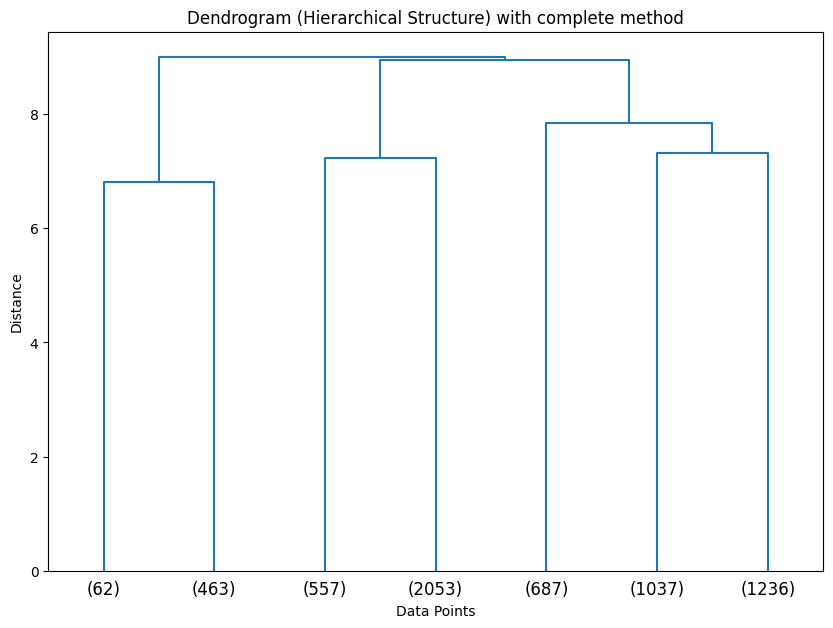

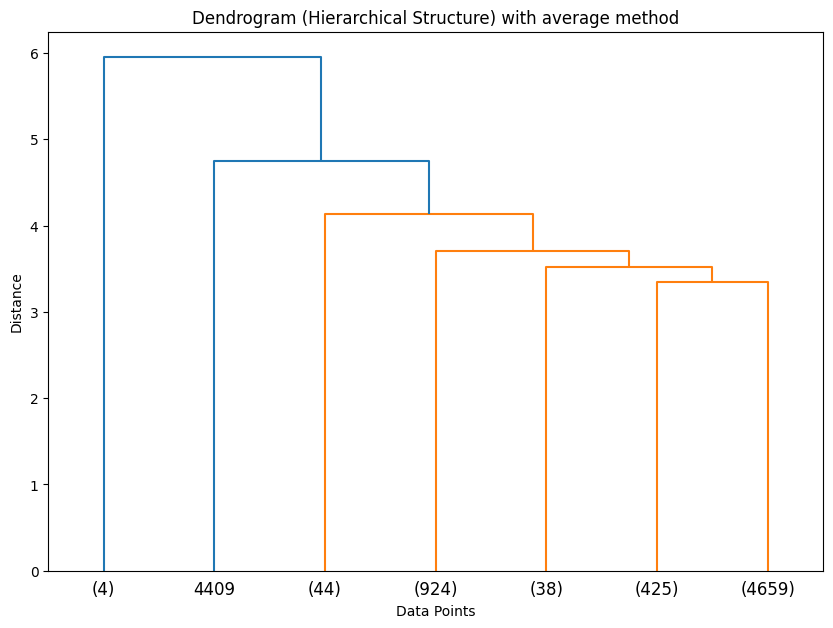

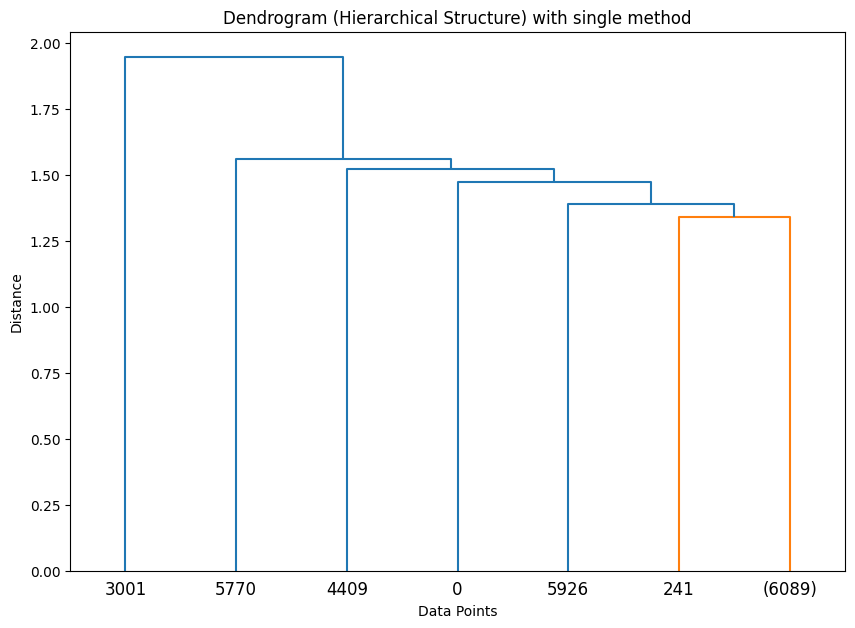

In [172]:
for method in ['ward', 'complete', 'average', 'single']:
    show_dendogram(std_numeric_cyclists, 7, method, 'euclidean')

### Complete search

The above results exhibit low silhouette scores, prompting the need for further exploration. To address this, we developed an algorithm that systematically searches for the optimal combinations of features (with a minimum of 3), linkage methods, and cluster numbers (up to a maximum of 8) for a fixed distance metric, with the goal of identifying configurations that maximize both the silhouette score and the cophenetic correlation. <br>
This approach can also be leveraged to automate feature selection, avoiding the need for manual evaluation and ensuring a more systematic exploration of feature subsets.

In [173]:
from itertools import combinations
from scipy.cluster.hierarchy import fcluster, cophenet


def combinations_result(normalized_dataset, max_cluster_to_test):
    columns = normalized_dataset.columns
    all_columns_subsets = []
    results = []
    for n_cluster in range(3, len(columns) + 1):  # Lunghezze da 1 a N
        subsets = combinations(columns, n_cluster)
        all_columns_subsets.extend([list(subset) for subset in subsets])
    for subset in all_columns_subsets:
        display(subset)
        normalized_dataset_subcolumns = normalized_dataset[subset]
        #cacola la distanza sulla base delle colonne: considero solo quelle per questa iterazione
        data_dist = pdist(normalized_dataset_subcolumns, metric='euclidean')
        for method in ['ward', 'single', 'complete', 'average']:
            # Perform hierarchical clustering for each method (only once per method)
            data_link = linkage(data_dist, method=method)
            # Compute the cophenetic correlation coefficient for the method
            coph_corr, coph_distances = cophenet(data_link, data_dist)
            for n_cluster in range(3, max_cluster_to_test + 1):
                # Generate clusters and evaluate silhouette scores for different cluster sizes
                clusters = fcluster(data_link, t=n_cluster, criterion='maxclust')
                result = silhouette_score(normalized_dataset_subcolumns, clusters)
                results.append({   
                    'method': method,
                    'clusters_size': np.unique(clusters, return_counts=True)[1],
                    'n_cluster': n_cluster,
                    'silhouette_score': result,
                    'coph_corr': coph_corr,
                    'features': subset
                })
    return pd.DataFrame(results)

def compute_and_save_combinations_result(normalized_dataset, max_cluster_to_test, output_file):
    results = combinations_result(normalized_dataset, max_cluster_to_test)
    results = results.sort_values(by='silhouette_score', ascending=False)
    results.to_csv(output_file, index=False)

Since this is a computationally expensive method, we save the results to a file to facilitate easy analysis at a later time.

In [ ]:
#compute_and_save_combinations_result(std_numeric_cyclists, 8, '../../dataset/cyclists_hierchical_cluster_search.csv')

By reading the file and sorting by silhouette score, we notice that many of the clusters that maximize the silhouette score are extremely unbalanced.

In [11]:
results = pd.read_csv('../../dataset/cyclists_hierchical_cluster_search.csv', sep=",")
pd.set_option('display.max_colwidth', None)  # Nessun limite
# Converte la colonna 'clusters_size' da stringa a lista
results['clusters_size'] = results['clusters_size'].apply(lambda x: list(map(int, x.strip("[]").split())))
results['features'] = results['features'].apply(lambda x: list(map(str, x.strip("[]").split(','))))
display(results.head(100))

,method,clusters_size,n_cluster,silhouette_score,coph_corr,features
0,single,"[2, 6092, 1]",3,0.612464,0.411604,"['AVG position', '# cyclist races', 'std_dev position']"
1,single,"[6093, 1, 1]",3,0.528655,0.530216,"['BMI', '# cyclist races', 'std_dev position']"
2,single,"[2, 6091, 1, 1]",4,0.517407,0.530216,"['BMI', '# cyclist races', 'std_dev position']"
3,single,"[2, 6092, 1]",3,0.516825,0.571955,"['BMI', 'AVG position', '# cyclist races']"
4,single,"[2, 6090, 1, 1, 1]",5,0.515908,0.571955,"['BMI', 'AVG position', '# cyclist races']"
...,...,...,...,...,...,...
95,ward,"[890, 1873, 1614, 1718]",4,0.289536,0.538601,"['BMI', '# cyclist races', 'birth_year']"
96,ward,"[709, 695, 311, 686, 1558, 2136]",6,0.289297,0.648123,"['AVG position', '# cyclist races', 'std_dev position']"
97,ward,"[983, 1316, 1194, 1471, 1131]",5,0.289296,0.579826,"['# cyclist races', 'birth_year', 'std_dev position']"
98,complete,"[961, 3038, 405, 1691]",4,0.288977,0.574638,"['AVG position', '# cyclist races', 'birth_year', 'std_dev position']"


By reading the file and sorting by silhouette score, we notice that many of the clusters that maximize the silhouette score are extremely unbalanced. In our analysis, we will focus on less imbalanced clusterings, excluding those that assign too many points to a single cluster, as they limit the range of analyses that can be effectively performed.

In [176]:
filtered_results = results[
    (results['clusters_size'].apply(lambda x: all(i < 4000 for i in x)))
    & (results['features'].apply(lambda x: len(x) >= 3))
].sort_values(by='silhouette_score', ascending=False)
display(filtered_results.head(100))

,method,clusters_size,n_cluster,silhouette_score,coph_corr,features
44,ward,"[1870, 1224, 3001]",3,0.372712,0.579416,"['AVG position', '# cyclist races', 'birth_year']"
47,ward,"[709, 695, 997, 3694]",4,0.361704,0.648123,"['AVG position', '# cyclist races', 'std_dev position']"
54,ward,"[1404, 997, 3694]",3,0.353109,0.648123,"['AVG position', '# cyclist races', 'std_dev position']"
68,average,"[36, 910, 3364, 1785]",4,0.321333,0.648899,"['# cyclist races', 'birth_year', 'std_dev position']"
83,ward,"[983, 1316, 1194, 2602]",4,0.303642,0.579826,"['# cyclist races', 'birth_year', 'std_dev position']"
...,...,...,...,...,...,...
224,ward,"[1510, 1083, 1297, 2205]",4,0.197817,0.475256,"['BMI', 'AVG position', 'birth_year']"
225,ward,"[1094, 2475, 663, 1863]",4,0.197364,0.544768,"['BMI', 'AVG position', 'birth_year', 'std_dev position']"
227,ward,"[595, 827, 244, 870, 1440, 964, 1155]",7,0.197015,0.524527,"['BMI', '# cyclist races', 'birth_year', 'std_dev position']"
228,ward,"[404, 1572, 677, 797, 242, 618, 671, 1114]",8,0.196735,0.536169,"['AVG position', 'birth_year', 'std_dev position']"


For each method, we select the top 4 rows with the highest silhouette scores. From these, we choose the row that represents the most reasonable combination by aiming to maximize the cophenetic correlation coefficient (cophenet) and prioritize combinations that include the highest number of features.

In [177]:
ward_res = filtered_results[filtered_results['method'] == 'ward'].head(4)
single_res = filtered_results[filtered_results['method'] == 'single'].head(4)
complete_res = filtered_results[filtered_results['method'] == 'complete'].head(4)
average_res = filtered_results[filtered_results['method'] == 'average'].head(4)

display(ward_res)
display(single_res)
display(complete_res)
display(average_res)

,method,clusters_size,n_cluster,silhouette_score,coph_corr,features
44,ward,"[1870, 1224, 3001]",3,0.372712,0.579416,"['AVG position', '# cyclist races', 'birth_year']"
47,ward,"[709, 695, 997, 3694]",4,0.361704,0.648123,"['AVG position', '# cyclist races', 'std_dev position']"
54,ward,"[1404, 997, 3694]",3,0.353109,0.648123,"['AVG position', '# cyclist races', 'std_dev position']"
83,ward,"[983, 1316, 1194, 2602]",4,0.303642,0.579826,"['# cyclist races', 'birth_year', 'std_dev position']"


,method,clusters_size,n_cluster,silhouette_score,coph_corr,features


,method,clusters_size,n_cluster,silhouette_score,coph_corr,features
98,complete,"[961, 3038, 405, 1691]",4,0.288977,0.574638,"['AVG position', '# cyclist races', 'birth_year', 'std_dev position']"
100,complete,"[65, 1171, 759, 1684, 2416]",5,0.287541,0.532421,"['AVG position', '# cyclist races', 'birth_year']"
107,complete,"[65, 337, 834, 759, 1684, 2416]",6,0.283758,0.532421,"['AVG position', '# cyclist races', 'birth_year']"
114,complete,"[961, 3038, 2096]",3,0.280429,0.574638,"['AVG position', '# cyclist races', 'birth_year', 'std_dev position']"


,method,clusters_size,n_cluster,silhouette_score,coph_corr,features
68,average,"[36, 910, 3364, 1785]",4,0.321333,0.648899,"['# cyclist races', 'birth_year', 'std_dev position']"
93,average,"[36, 735, 175, 3364, 1785]",5,0.290712,0.648899,"['# cyclist races', 'birth_year', 'std_dev position']"
113,average,"[30, 542, 1575, 3948]",4,0.280554,0.660653,"['AVG position', '# cyclist races', 'birth_year', 'std_dev position']"
124,average,"[828, 467, 38, 541, 1042, 2684, 14, 481]",8,0.267224,0.732147,"['AVG position', '# cyclist races', 'std_dev position']"


### Understanding cluster results

To visualize the results for the best-performing methods, we will generate both dendrograms and scatter plots.

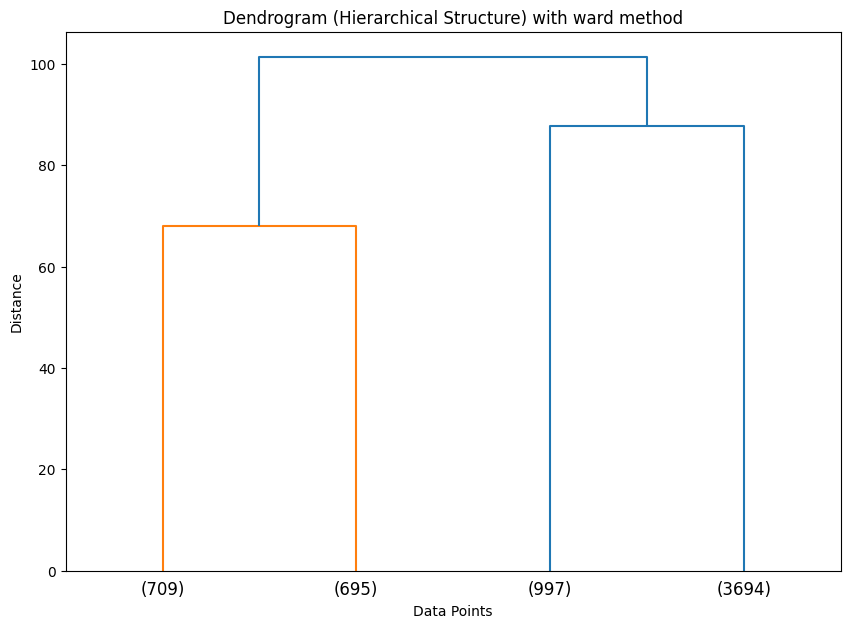

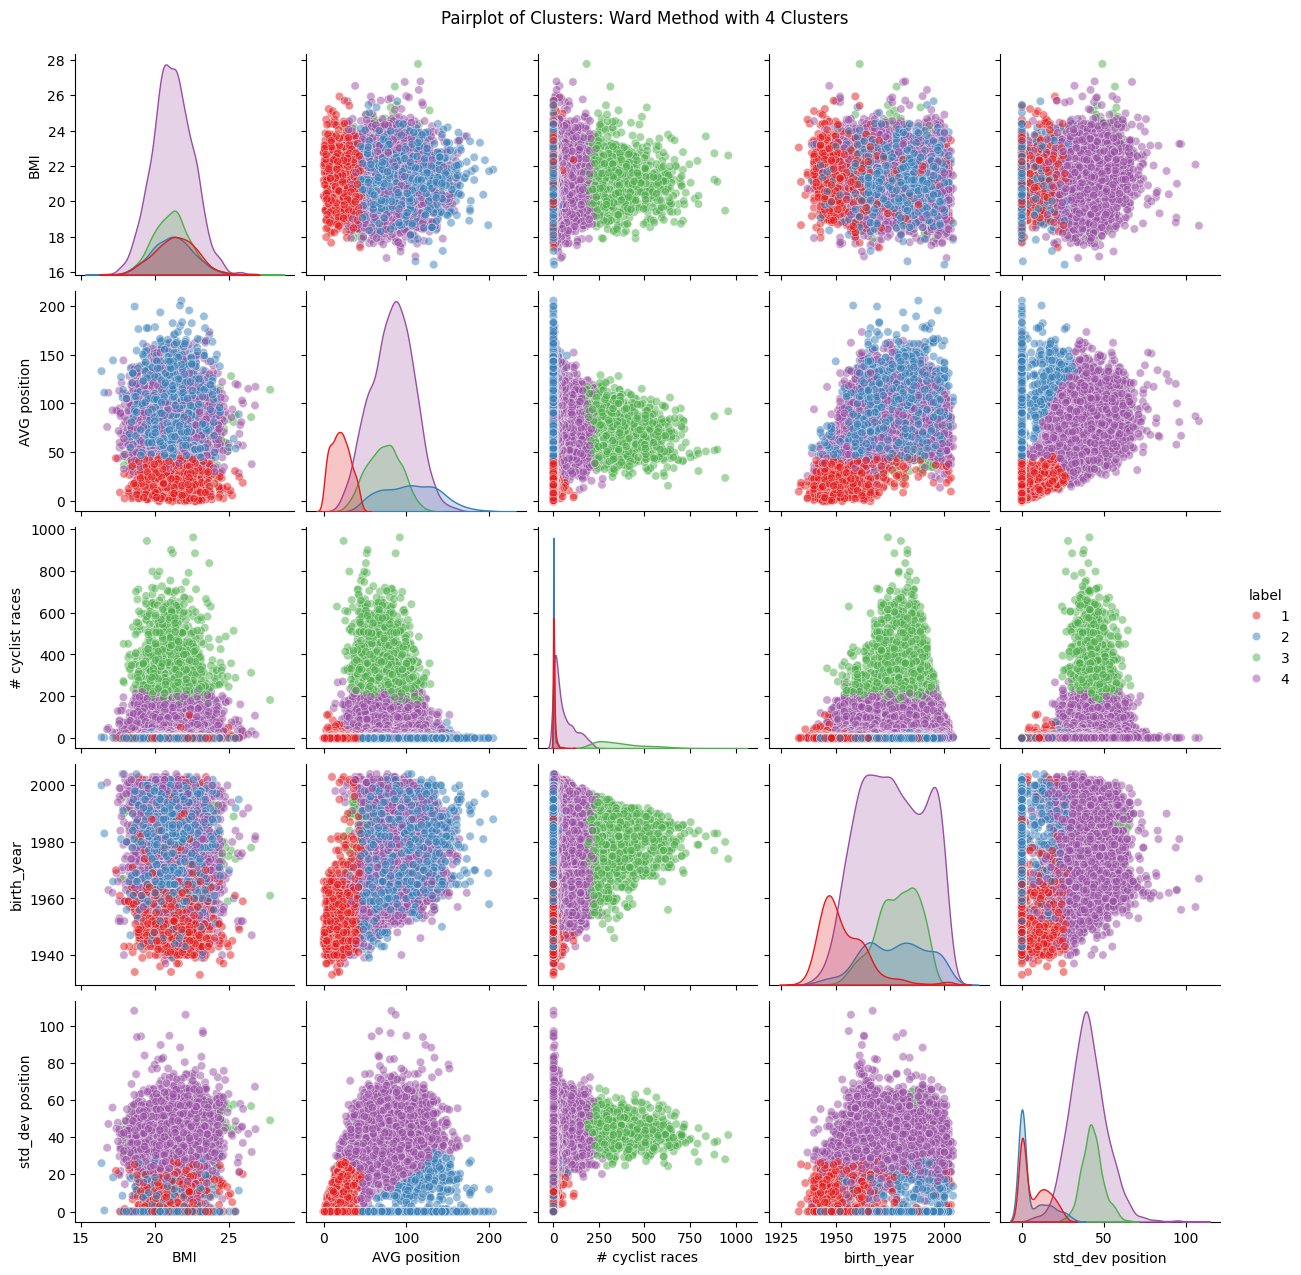

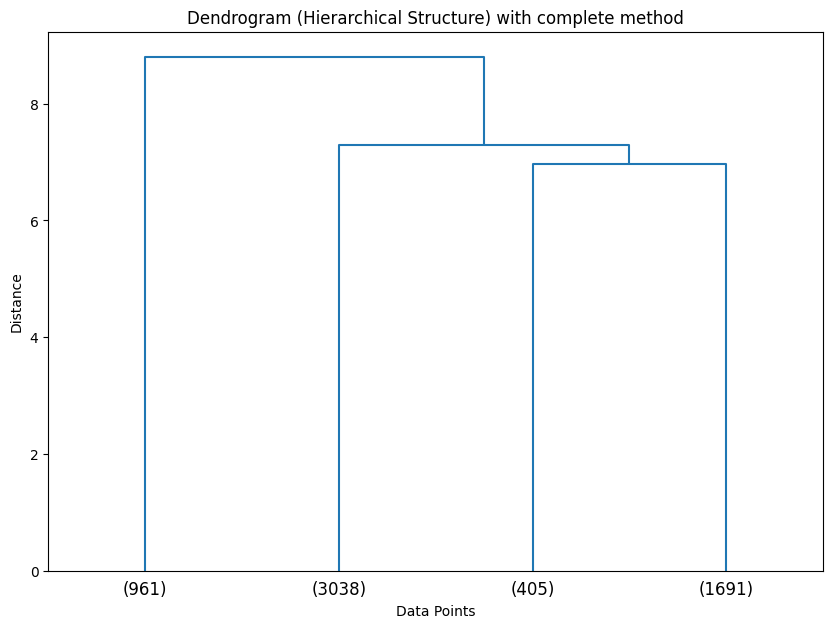

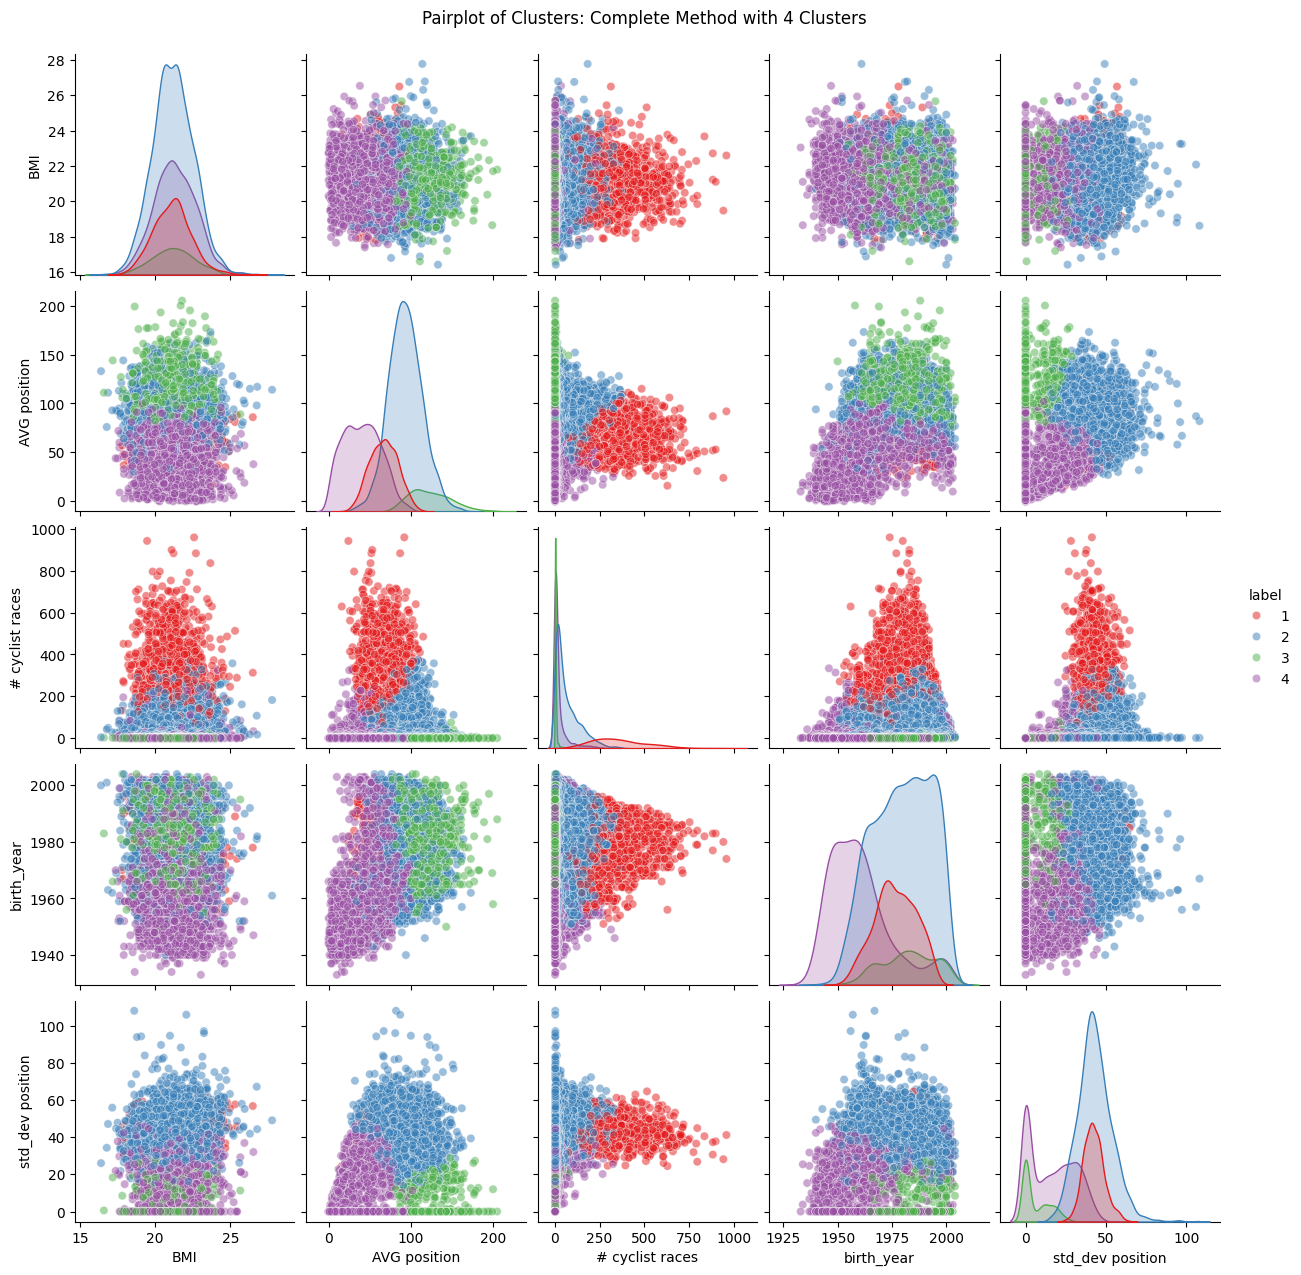

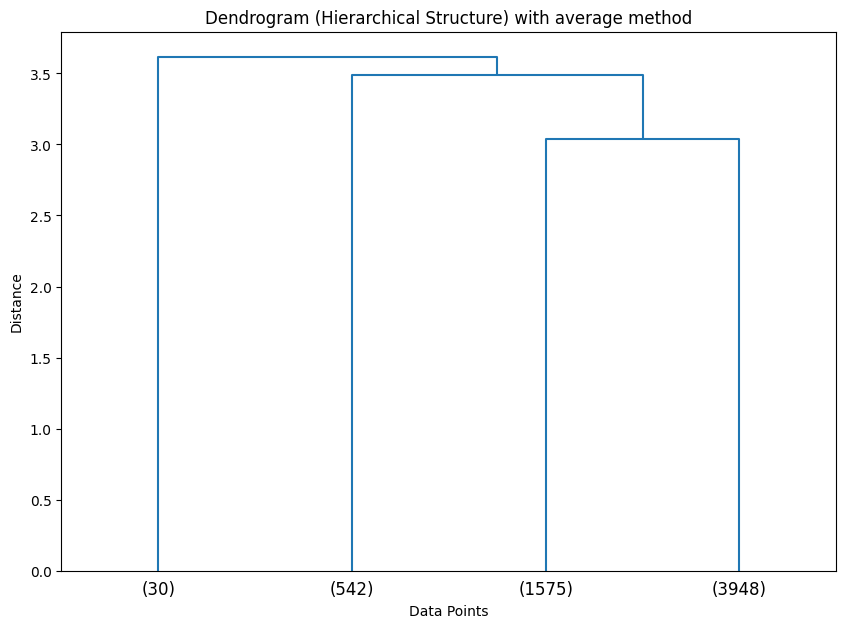

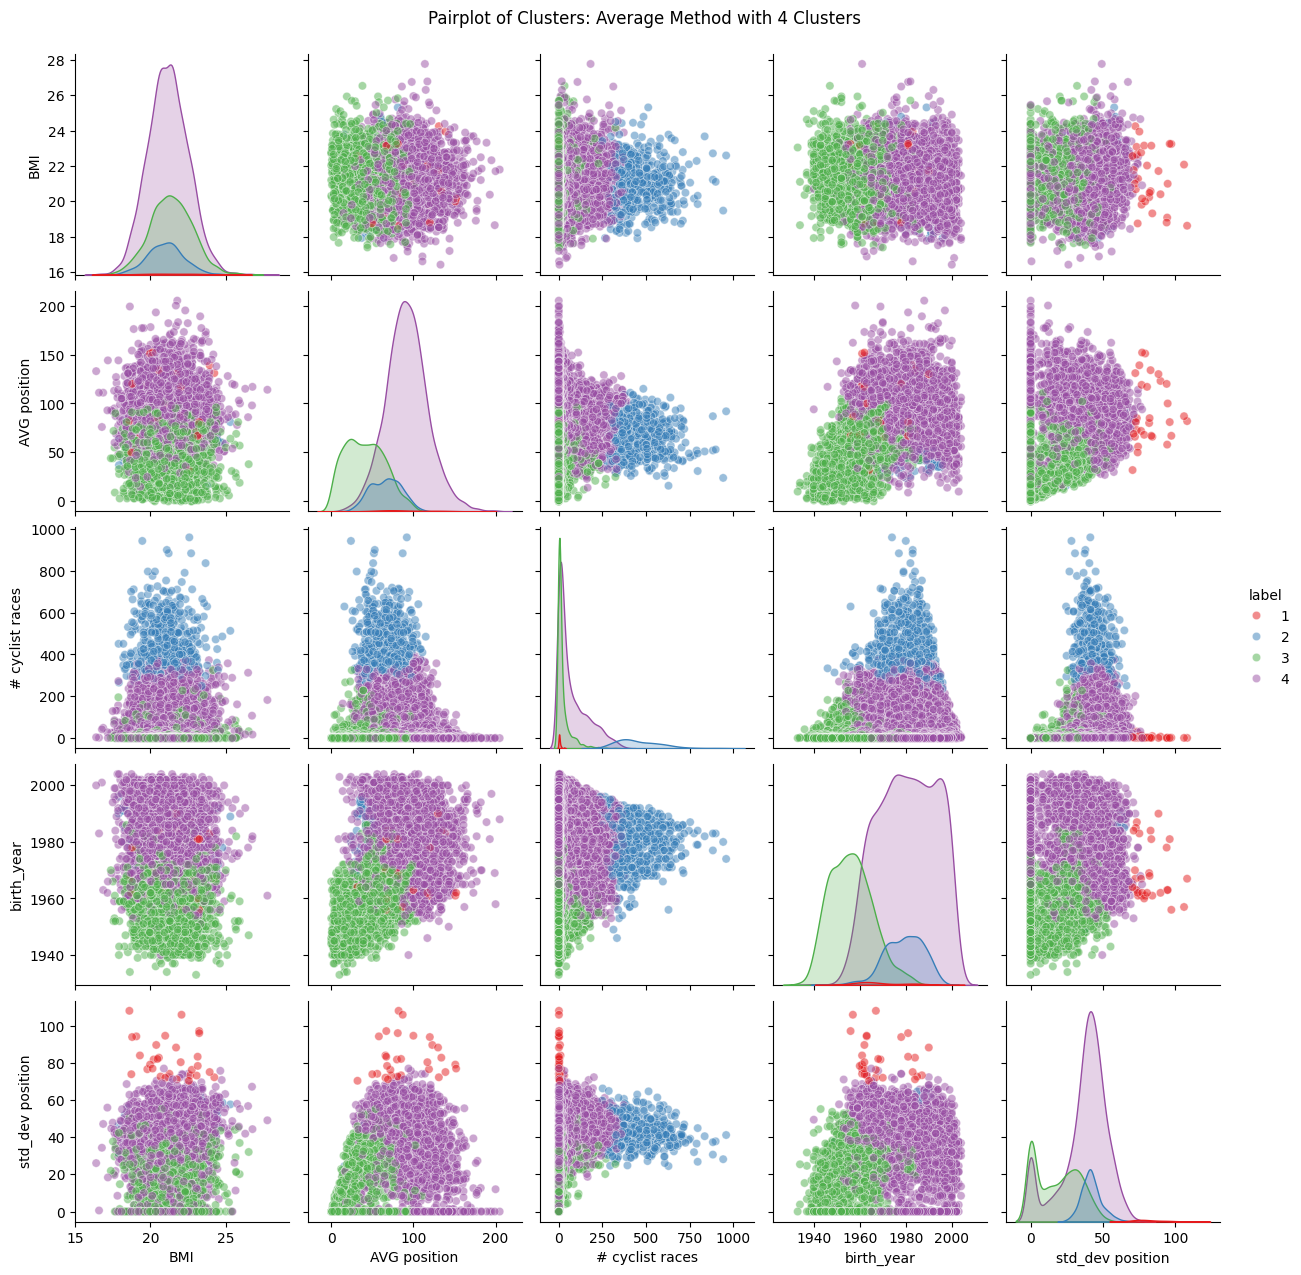

In [178]:
best_results = [
    {
        "method": "ward",
        "cluster_sizes": [709, 695, 997, 3694],
        "n_cluster": 4,
        "silhouette_score": 0.361704,
        "coph_corr": 0.648123,
        "features": ["AVG position", "# cyclist races", "std_dev position"]
    },
    {
        "method": "complete",
        "cluster_sizes": [961, 3038, 405, 1691]	,
        "n_cluster": 4,
        "silhouette_score": 0.288977,
        "coph_corr": 0.574638,
        "features": ['AVG position', '# cyclist races', 'birth_year', 'std_dev position']
    },
    {
        "method": "average",
        "cluster_sizes": [30, 542, 1575, 3948],
        "n_cluster": 4,
        "silhouette_score": 0.280554,
        "coph_corr": 0.660653,
        "features": ["AVG position", "# cyclist races", "birth_year", "std_dev position"]
    }
]

for result in best_results:
    show_dendogram(std_numeric_cyclists[result["features"]], 
                   result["n_cluster"], result["method"], 'euclidean')
    labels = retrieve_clusters_and_score(std_numeric_cyclists[result["features"]], 
                   result["n_cluster"], result["method"], 'euclidean')['clusters']
    to_visualize = cyclists_working_dataset.copy()
    to_visualize.loc[:, 'label'] = labels
    # Generate pairplot with a title
    pairplot = sbn.pairplot(data=to_visualize, hue='label', palette='Set1', plot_kws={'alpha': 0.5})
    pairplot.figure.suptitle(f"Pairplot of Clusters: {result['method'].capitalize()} Method "
                      f"with {result['n_cluster']} Clusters", 
                      y=1.02)  # Adjust title position slightly above the plot
    plt.show()
    plt.close()
    

We will analyze the clusters using the average configuration, which considers 4 out of 5 columns and achieves a good silhouette score.

In [179]:
result_to_analyze = {
        "method": "average",
        "cluster_sizes": [30, 542, 1575, 3948],
        "n_cluster": 4,
        "silhouette_score": 0.280554,
        "coph_corr": 0.660653,
        "features": ["AVG position", "# cyclist races", "birth_year", "std_dev position"]
}

### Analyzing Feature Distribution Segmented by Cluster

With this conditional boxplot, we analyze how the distribution of various features changes when segmented by the cluster labels. This visualization helps us understand the specific characteristics of each cluster, highlighting differences in feature ranges, medians, and variability.

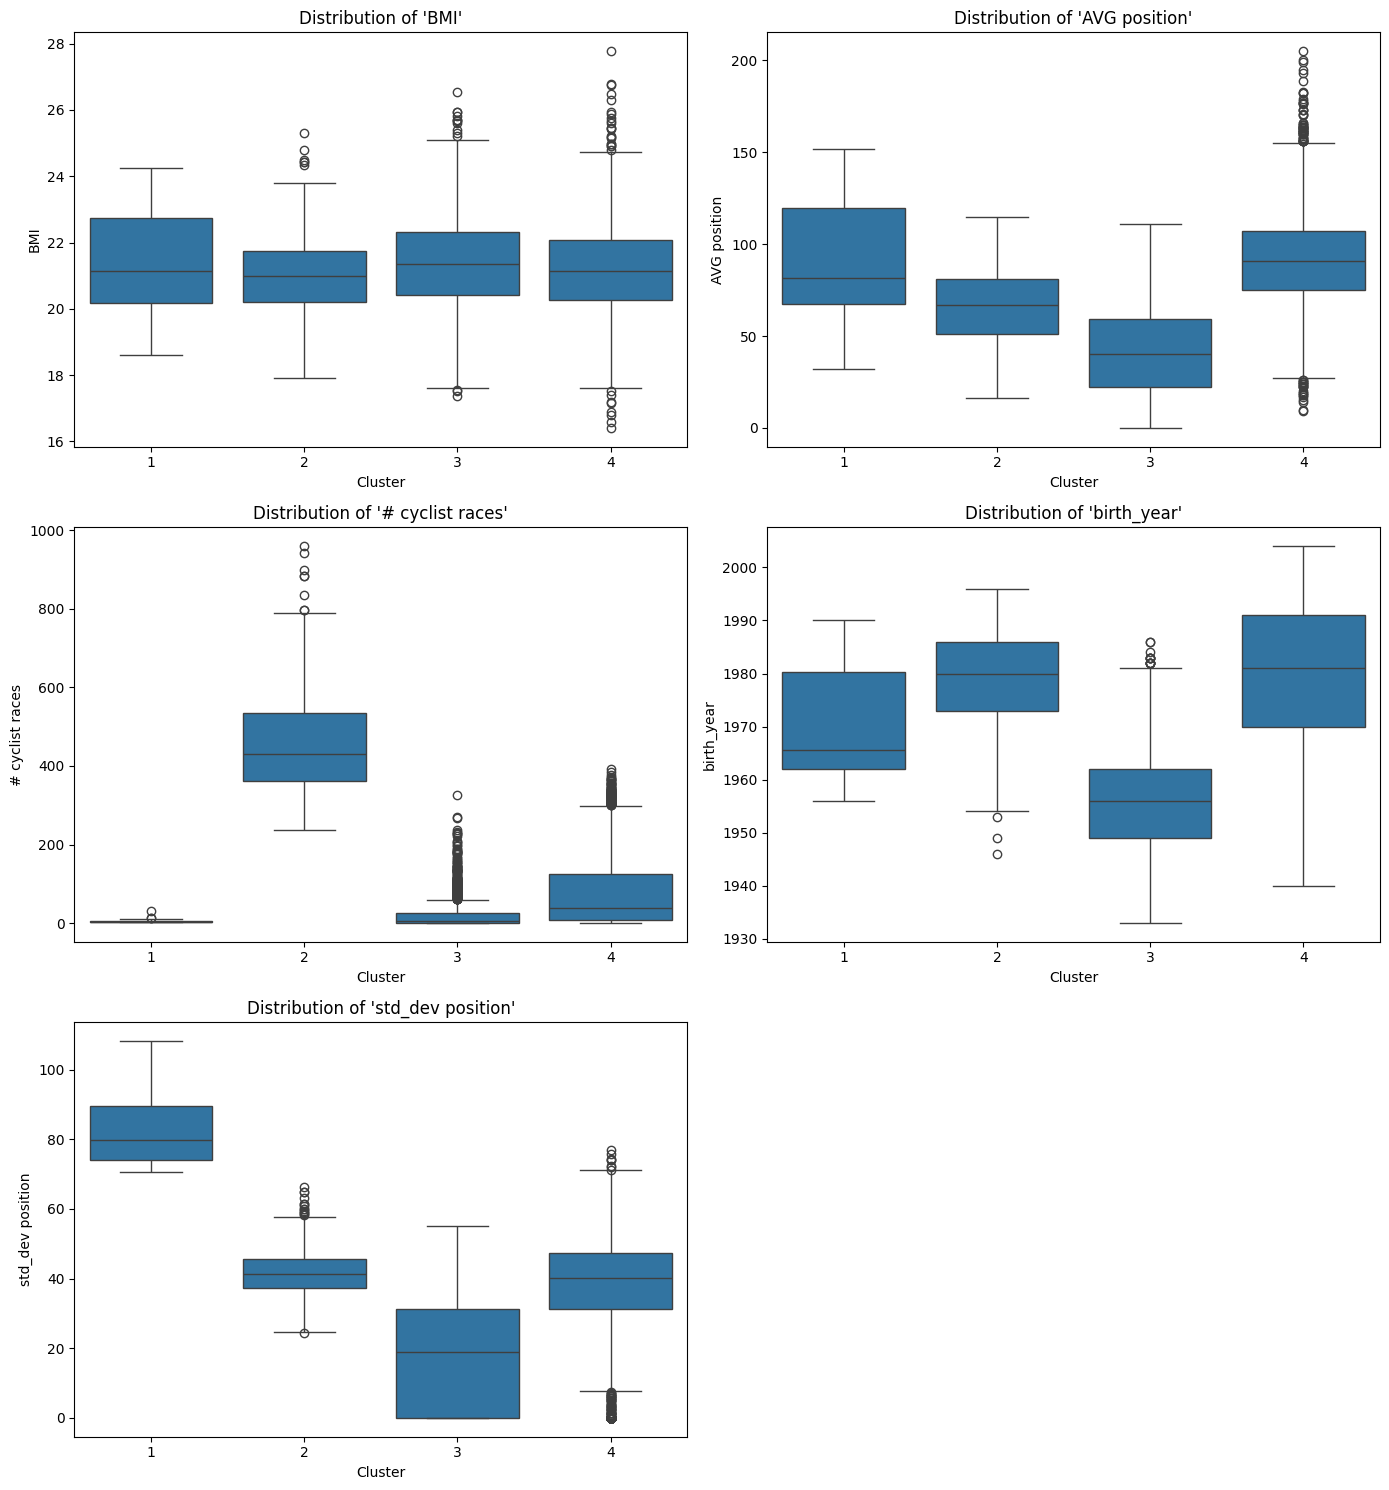

In [180]:
from clustering_utility import clusters_conditional_box_plot

labels = retrieve_clusters_and_score(std_numeric_cyclists[result_to_analyze["features"]], 
result_to_analyze["n_cluster"], result_to_analyze["method"], 'euclidean')['clusters']
to_visualize = cyclists_working_dataset.copy()
to_visualize.loc[:, 'label'] = labels

clusters_conditional_box_plot(to_visualize, 'label')


### Geographic distribution of cyclists across clusters
This approach serves as the categorical equivalent of analyzing feature distributions across clusters, similar to using boxplots for numerical features. By segmenting and visualizing counts of categorical variables (e.g., geographic regions) within each cluster, we can understand how clusters are composed and how categorical data varies across them. In this case, we analyzed the geographic distribution of cyclists across clusters by grouping them based on their geographic area and visualizing the results. <br> 
A bar chart was used to compare the counts of cyclists from different regions within each cluster, highlighting the relationships between geographic regions and cluster assignments and providing insights into how cyclists from various areas are distributed across the clusters.

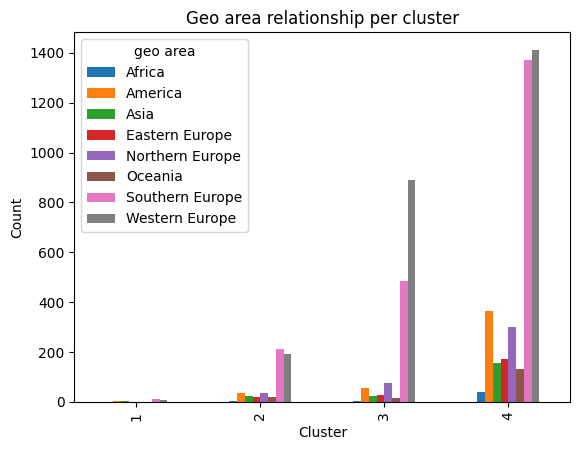

In [181]:
cross_df = pd.crosstab(labels, cyclists['geo area'])

cross_df.plot(kind='bar', stacked=False, title='Geo area relationship per cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

# Races

## Correlation matrix

In [220]:
races['date'] = pd.to_datetime(races['date'])
races_numeric_columns = ['points', 'uci_points', 'length', 'climb_total',
       'startlist_quality', 'average_temperature', 'date', 'climb/length', 'median_delta', 'std_delta']

As with the cyclists dataset, we analyze the correlations between columns after imputation phase to identify and remove redundant features, reducing redundancy and ensuring that each column contributes unique information and important to the analysis.

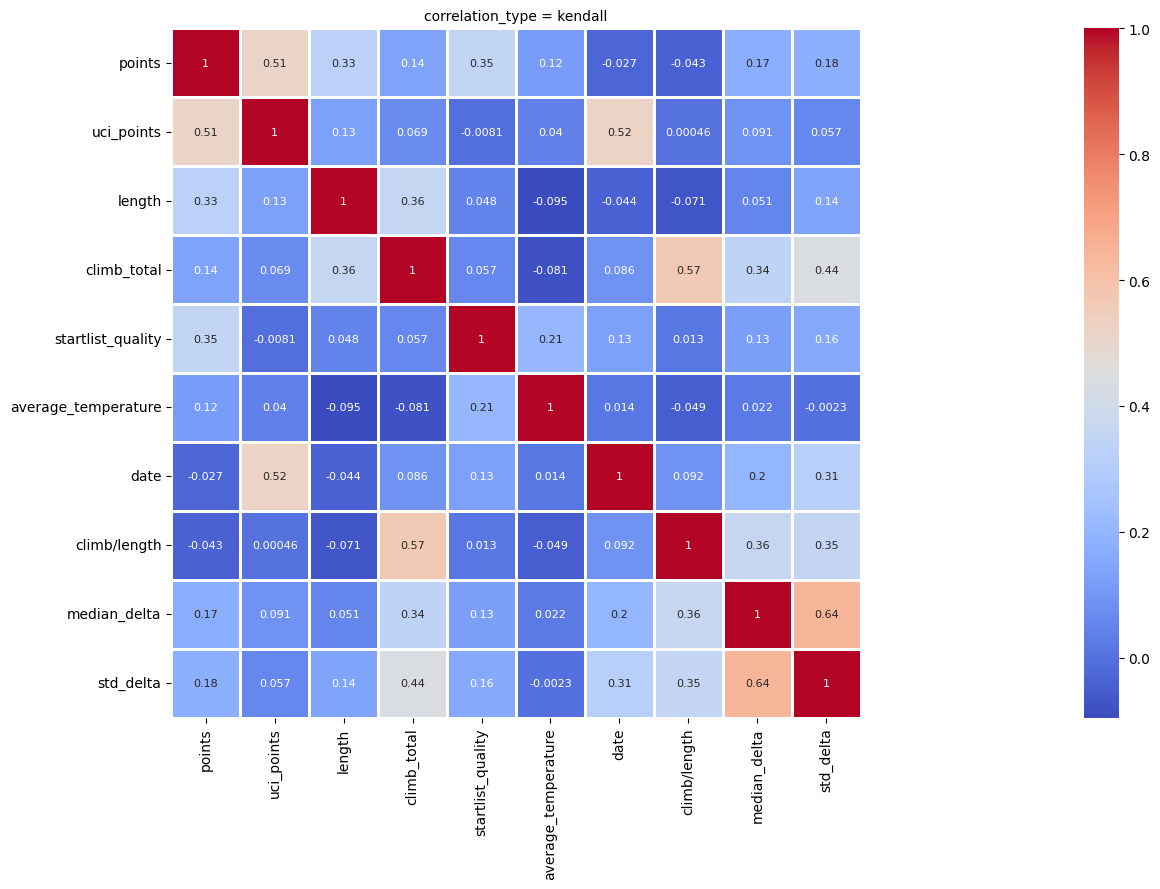

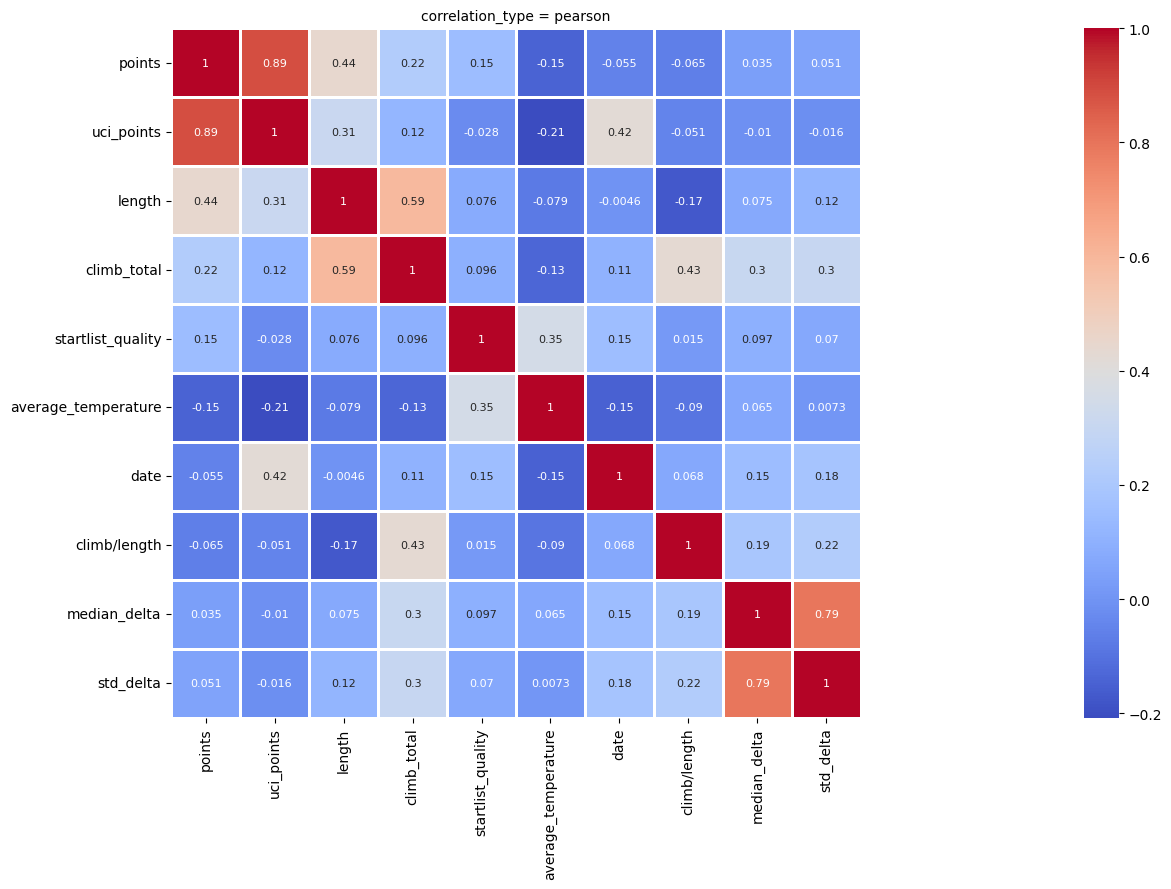

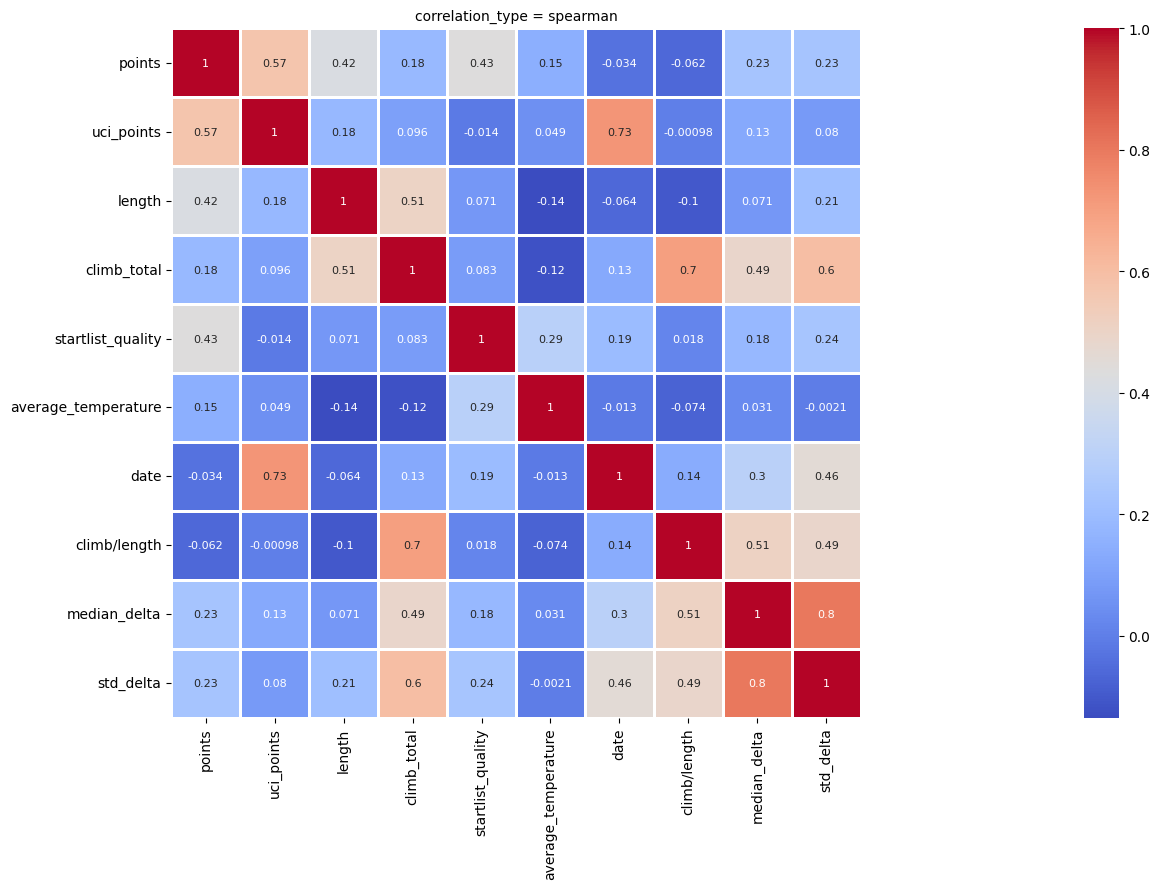

In [221]:
for method in ['kendall', 'pearson', 'spearman']:
    show_heatmap(races, columns = races_numeric_columns, correlation_method = method)

After analyzing the correlation matrices, we identify uci_points and median_delta as redundant features. uci_points is highly correlated with points, and median_delta is highly correlated with std_delta, making them unnecessary for further analysis. Therefore, we remove these columns to reduce redundancy.

As previously observed, we also remove average_temperature because it contains too many null values.

In [184]:
stats_on_missing_values(races)

,Feature,Null_counter,Perc_of_null_(%)
0,_url,0,0.0
1,name,0,0.0
2,points,0,0.0
3,uci_points,3682,69.7
4,length,0,0.0
5,climb_total,0,0.0
6,profile,2408,45.6
7,startlist_quality,0,0.0
8,average_temperature,5076,96.1
9,is_tarmac,0,0.0


## Clustering

### Standardization

In [223]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columns = ['points', 'length', 'climb_total', 'climb/length', 'median_delta', 'startlist_quality']
races_working_dataset = races[columns]
# Fit the scaler only once per subset
scaler.fit(races_working_dataset)
std_numeric_races = pd.DataFrame(scaler.transform(races_working_dataset), columns=columns)
display(std_numeric_races)

,points,length,climb_total,climb/length,median_delta,startlist_quality
0,0.171536,-0.054293,-0.848164,-0.759354,-0.332395,0.663219
1,-0.154268,0.446565,2.554485,1.508052,1.655025,-0.440839
2,0.171536,-0.555152,-1.091537,-0.832122,-0.330335,1.867167
3,-0.642976,-2.321415,-1.633801,-0.591897,-0.305621,-0.485527
4,0.171536,0.400899,1.161178,0.561182,1.056740,1.478119
...,...,...,...,...,...,...
5276,-0.154268,-0.260529,-0.589581,-0.451394,-0.280907,-0.283116
5277,3.022329,1.580862,0.328389,-0.455254,-0.082165,-0.475012
5278,-0.642976,0.284523,-0.372828,-0.493998,-0.360198,-0.551244
5279,-0.642976,-0.431411,-0.255705,-0.027555,-0.144980,0.147992


### Initial analysis

As before, we perform an initial analysis using a reasonable number of clusters and all the low-correlated columns to gain an overview of the clustering structure and evaluate preliminary patterns. <br>
This serves as a starting point for deeper exploration and refinement in subsequent steps.

In [186]:
simple_result = []
for method in ['ward', 'complete', 'average', 'single']:
    cluster_score_5 = retrieve_clusters_and_score(std_numeric_races, 5, method, 'euclidean')
    cluster_score_6 = retrieve_clusters_and_score(std_numeric_races, 6, method, 'euclidean')
    cluster_score_7 = retrieve_clusters_and_score(std_numeric_races, 7, method, 'euclidean')
    simple_result.append(cluster_score_5)
    simple_result.append(cluster_score_6)
    simple_result.append(cluster_score_7)
display(pd.DataFrame(simple_result))

,method,clusters,clusters_size,n_cluster,silhouette_score,coph_corr
0,ward,"[5, 4, 5, 2, 4, 4, 2, 5, 2, 2, 5, 4, 4, 1, 4, 1, 5, 5, 4, 5, 5, 2, 5, 5, 2, 4, 2, 5, 5, 5, 5, 2, 5, 5, 5, 4, 5, 4, 5, 4, 5, 4, 2, 5, 4, 5, 5, 5, 1, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 5, 5, 2, 5, 5, 5, 2, 5, 1, 4, 5, 5, 5, 1, 5, 4, 5, 4, 5, 5, 2, 4, 5, 5, 5, 2, 5, 5, 4, 5, 2, 4, 2, 5, 4, 5, 5, 5, 5, ...]","[509, 768, 3, 727, 3274]",5,0.314824,0.509806
1,ward,"[5, 4, 5, 2, 4, 4, 2, 6, 2, 2, 6, 4, 4, 1, 4, 1, 6, 6, 4, 6, 6, 2, 6, 6, 2, 4, 2, 6, 6, 6, 5, 2, 6, 6, 6, 4, 6, 4, 6, 4, 5, 4, 2, 6, 4, 6, 6, 6, 1, 6, 4, 6, 6, 6, 6, 6, 6, 6, 6, 4, 4, 6, 6, 2, 6, 6, 6, 2, 6, 1, 4, 6, 5, 6, 1, 6, 4, 5, 4, 6, 6, 2, 4, 6, 6, 6, 2, 6, 5, 4, 5, 2, 4, 2, 5, 4, 6, 6, 6, 6, ...]","[509, 768, 3, 727, 652, 2622]",6,0.329760,0.509806
2,ward,"[6, 5, 6, 2, 5, 5, 2, 7, 2, 2, 7, 5, 5, 1, 5, 1, 7, 7, 5, 7, 7, 2, 7, 7, 2, 5, 2, 7, 7, 7, 6, 2, 7, 7, 7, 5, 7, 5, 7, 5, 6, 5, 2, 7, 5, 7, 7, 7, 1, 7, 5, 7, 7, 7, 7, 7, 7, 7, 7, 5, 5, 7, 7, 2, 7, 7, 7, 2, 7, 1, 5, 7, 6, 7, 1, 7, 5, 6, 5, 7, 7, 2, 5, 7, 7, 7, 2, 7, 6, 5, 6, 2, 5, 2, 6, 5, 7, 7, 7, 7, ...]","[509, 724, 44, 3, 727, 652, 2622]",7,0.338463,0.509806
3,complete,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...]","[2, 1, 20, 5257, 1]",5,0.658635,0.765931
4,complete,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...]","[2, 1, 20, 82, 5175, 1]",6,0.359857,0.765931
5,complete,"[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...]","[1, 1, 1, 20, 82, 5175, 1]",7,0.359670,0.765931
6,average,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...]","[2, 1, 2, 5275, 1]",5,0.740492,0.884812
7,average,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...]","[1, 1, 1, 2, 5275, 1]",6,0.740305,0.884812
8,average,"[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...]","[1, 1, 1, 2, 55, 5220, 1]",7,0.547847,0.884812
9,single,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...]","[1, 1, 1, 5277, 1]",5,0.888455,0.777773



As we can observe from the initial analysis, the clustering results using the linkage methods complete, average, and single are highly imbalanced, with certain clusters dominating in size. These methods achieve significantly higher silhouette scores and cophenetic correlations, suggesting that they may capture some global patterns in the data. However, their extreme imbalance in cluster sizes, such as clusters with 5200 points and others with single points, makes meaningful analysis nearly impossible.

On the other hand, the ward method produces more balanced cluster sizes, which may make it more suitable for a detailed analysis of the data. By ensuring that clusters are not dominated by a single group, the ward method could reveal more meaningful variations and distinctions across the data, making it a better choice for this context despite its relatively lower silhouette and cophenetic correlation values.

### Complete search

As before, we perform an analysis of the various combinations of features and linkage methods to systematically identify the best configurations. This approach allows us to efficiently explore the options and pinpoint the combination that delivers the most meaningful and interpretable clustering results.

In [187]:
#compute_and_save_combinations_result(std_numeric_races, 8, '../dataset/races_hierchical_cluster_search.csv')

In [ ]:
results = pd.read_csv('../../dataset/races_hierchical_cluster_search.csv', sep=",")
pd.set_option('display.max_colwidth', None)  # Nessun limite
# Converte la colonna 'clusters_size' da stringa a lista
results['clusters_size'] = results['clusters_size'].apply(lambda x: list(map(int, x.strip("[]").split())))
results['features'] = results['features'].apply(lambda x: list(map(str, x.strip("[]").split(','))))
display(results.head(100))

,method,clusters_size,n_cluster,silhouette_score,coph_corr,features
0,average,"[3, 5277, 1]",3,0.948688,0.938067,"['points', 'climb/length', 'median_delta']"
1,single,"[3, 5277, 1]",3,0.948688,0.856164,"['points', 'climb/length', 'median_delta']"
2,complete,"[3, 5277, 1]",3,0.948688,0.912847,"['points', 'climb/length', 'median_delta']"
3,average,"[3, 5277, 1]",3,0.946966,0.898947,"['climb_total', 'climb/length', 'median_delta']"
4,single,"[3, 5277, 1]",3,0.946966,0.786577,"['climb_total', 'climb/length', 'median_delta']"
...,...,...,...,...,...,...
95,average,"[5278, 1, 1, 1]",4,0.926425,0.892292,"['length', 'median_delta', 'startlist_quality']"
96,single,"[5278, 1, 1, 1]",4,0.926425,0.770706,"['length', 'median_delta', 'startlist_quality']"
97,complete,"[5278, 1, 1, 1]",4,0.926425,0.760076,"['length', 'median_delta', 'startlist_quality']"
98,single,"[5278, 1, 1, 1]",4,0.926315,0.779687,"['climb_total', 'median_delta', 'startlist_quality']"


As before, the configurations with the highest silhouette and cophenetic correlation values create highly imbalanced clusters (e.g., clusters with 5277 points and single-point clusters), making meaningful analysis impossible. These extreme imbalances fail to provide useful insights into the structure of the data. To address this, we filter out the most imbalanced configurations and focus on those that use the highest number of features, maintain reasonably balanced clusters, and achieve high silhouette scores and cophenetic correlation values.

In [189]:
filtered_results = results[
    (results['clusters_size'].apply(lambda x: all(i < 4000 for i in x)))
    & (results['features'].apply(lambda x: len(x) >= 4))
].sort_values(by='silhouette_score', ascending=False)
display(filtered_results.head(100))

,method,clusters_size,n_cluster,silhouette_score,coph_corr,features
452,ward,"[3984, 509, 788]",3,0.510791,0.528452,"['points', 'climb_total', 'climb/length', 'median_delta']"
466,ward,"[3984, 509, 3, 785]",4,0.503480,0.528452,"['points', 'climb_total', 'climb/length', 'median_delta']"
470,ward,"[3952, 817, 509, 3]",4,0.502482,0.549603,"['points', 'length', 'climb/length', 'median_delta']"
489,ward,"[3952, 766, 51, 509, 3]",5,0.490067,0.549603,"['points', 'length', 'climb/length', 'median_delta']"
500,ward,"[3877, 892, 3, 509]",4,0.481545,0.543878,"['points', 'climb/length', 'median_delta', 'startlist_quality']"
...,...,...,...,...,...,...
850,average,"[509, 1, 7, 121, 593, 810, 61, 3179]",8,0.297321,0.799144,"['points', 'length', 'climb_total', 'startlist_quality']"
853,ward,"[2339, 3, 877, 2062]",4,0.296676,0.340702,"['climb_total', 'climb/length', 'median_delta', 'startlist_quality']"
854,complete,"[3944, 509, 122, 703, 1, 1, 1]",7,0.296329,0.752645,"['points', 'climb_total', 'median_delta', 'startlist_quality']"
857,ward,"[509, 698, 3, 547, 652, 776, 1020, 1076]",8,0.295713,0.588230,"['points', 'length', 'climb_total', 'median_delta']"


For each method, we select the top 4 rows with the highest silhouette scores. From these, we choose the row that represents the most reasonable combination by aiming to maximize the cophenetic correlation coefficient (cophenet) and prioritize combinations that include the highest number of features.

In [190]:
ward_res = filtered_results[filtered_results['method'] == 'ward'].head(5)
single_res = filtered_results[filtered_results['method'] == 'single'].head(5)
complete_res = filtered_results[filtered_results['method'] == 'complete'].head(5)
average_res = filtered_results[filtered_results['method'] == 'average'].head(5)

display(ward_res)
display(single_res)
display(complete_res)
display(average_res)

,method,clusters_size,n_cluster,silhouette_score,coph_corr,features
452,ward,"[3984, 509, 788]",3,0.510791,0.528452,"['points', 'climb_total', 'climb/length', 'median_delta']"
466,ward,"[3984, 509, 3, 785]",4,0.503480,0.528452,"['points', 'climb_total', 'climb/length', 'median_delta']"
470,ward,"[3952, 817, 509, 3]",4,0.502482,0.549603,"['points', 'length', 'climb/length', 'median_delta']"
489,ward,"[3952, 766, 51, 509, 3]",5,0.490067,0.549603,"['points', 'length', 'climb/length', 'median_delta']"
500,ward,"[3877, 892, 3, 509]",4,0.481545,0.543878,"['points', 'climb/length', 'median_delta', 'startlist_quality']"


,method,clusters_size,n_cluster,silhouette_score,coph_corr,features


,method,clusters_size,n_cluster,silhouette_score,coph_corr,features
531,complete,"[510, 864, 3856, 34, 16, 1]",6,0.458956,0.760624,"['points', 'length', 'climb_total', 'climb/length']"
588,complete,"[509, 892, 3877, 1, 1, 1]",6,0.424629,0.855532,"['points', 'length', 'median_delta', 'startlist_quality']"
593,complete,"[5, 875, 3283, 606, 509, 1, 1, 1]",8,0.423183,0.801793,"['points', 'length', 'climb_total', 'median_delta']"
631,complete,"[27, 884, 510, 3859, 1]",5,0.395688,0.758027,"['points', 'length', 'climb/length', 'startlist_quality']"
634,complete,"[24, 3, 884, 510, 3859, 1]",6,0.394396,0.758027,"['points', 'length', 'climb/length', 'startlist_quality']"


,method,clusters_size,n_cluster,silhouette_score,coph_corr,features
528,average,"[510, 862, 3858, 14, 34, 1, 1, 1]",8,0.462152,0.848278,"['points', 'length', 'climb_total', 'climb/length']"
533,average,"[509, 726, 838, 3204, 1, 1, 1, 1]",8,0.457533,0.902532,"['points', 'length', 'median_delta', 'startlist_quality']"
663,average,"[510, 7, 714, 810, 3240]",5,0.381653,0.799144,"['points', 'length', 'climb_total', 'startlist_quality']"
671,average,"[707, 3833, 737, 1, 1, 1, 1]",7,0.378294,0.874211,"['length', 'climb_total', 'median_delta', 'startlist_quality']"
703,average,"[509, 1, 7, 714, 810, 3240]",6,0.360126,0.799144,"['points', 'length', 'climb_total', 'startlist_quality']"


### Understanding cluster results

From the grids above we extract the best configurations and display a dendogram and a scatterplot for each of them

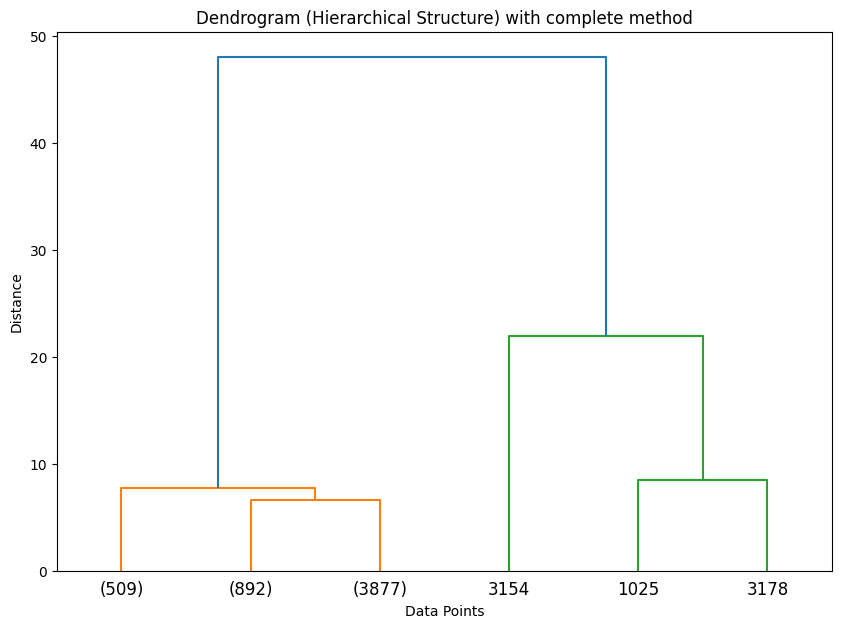

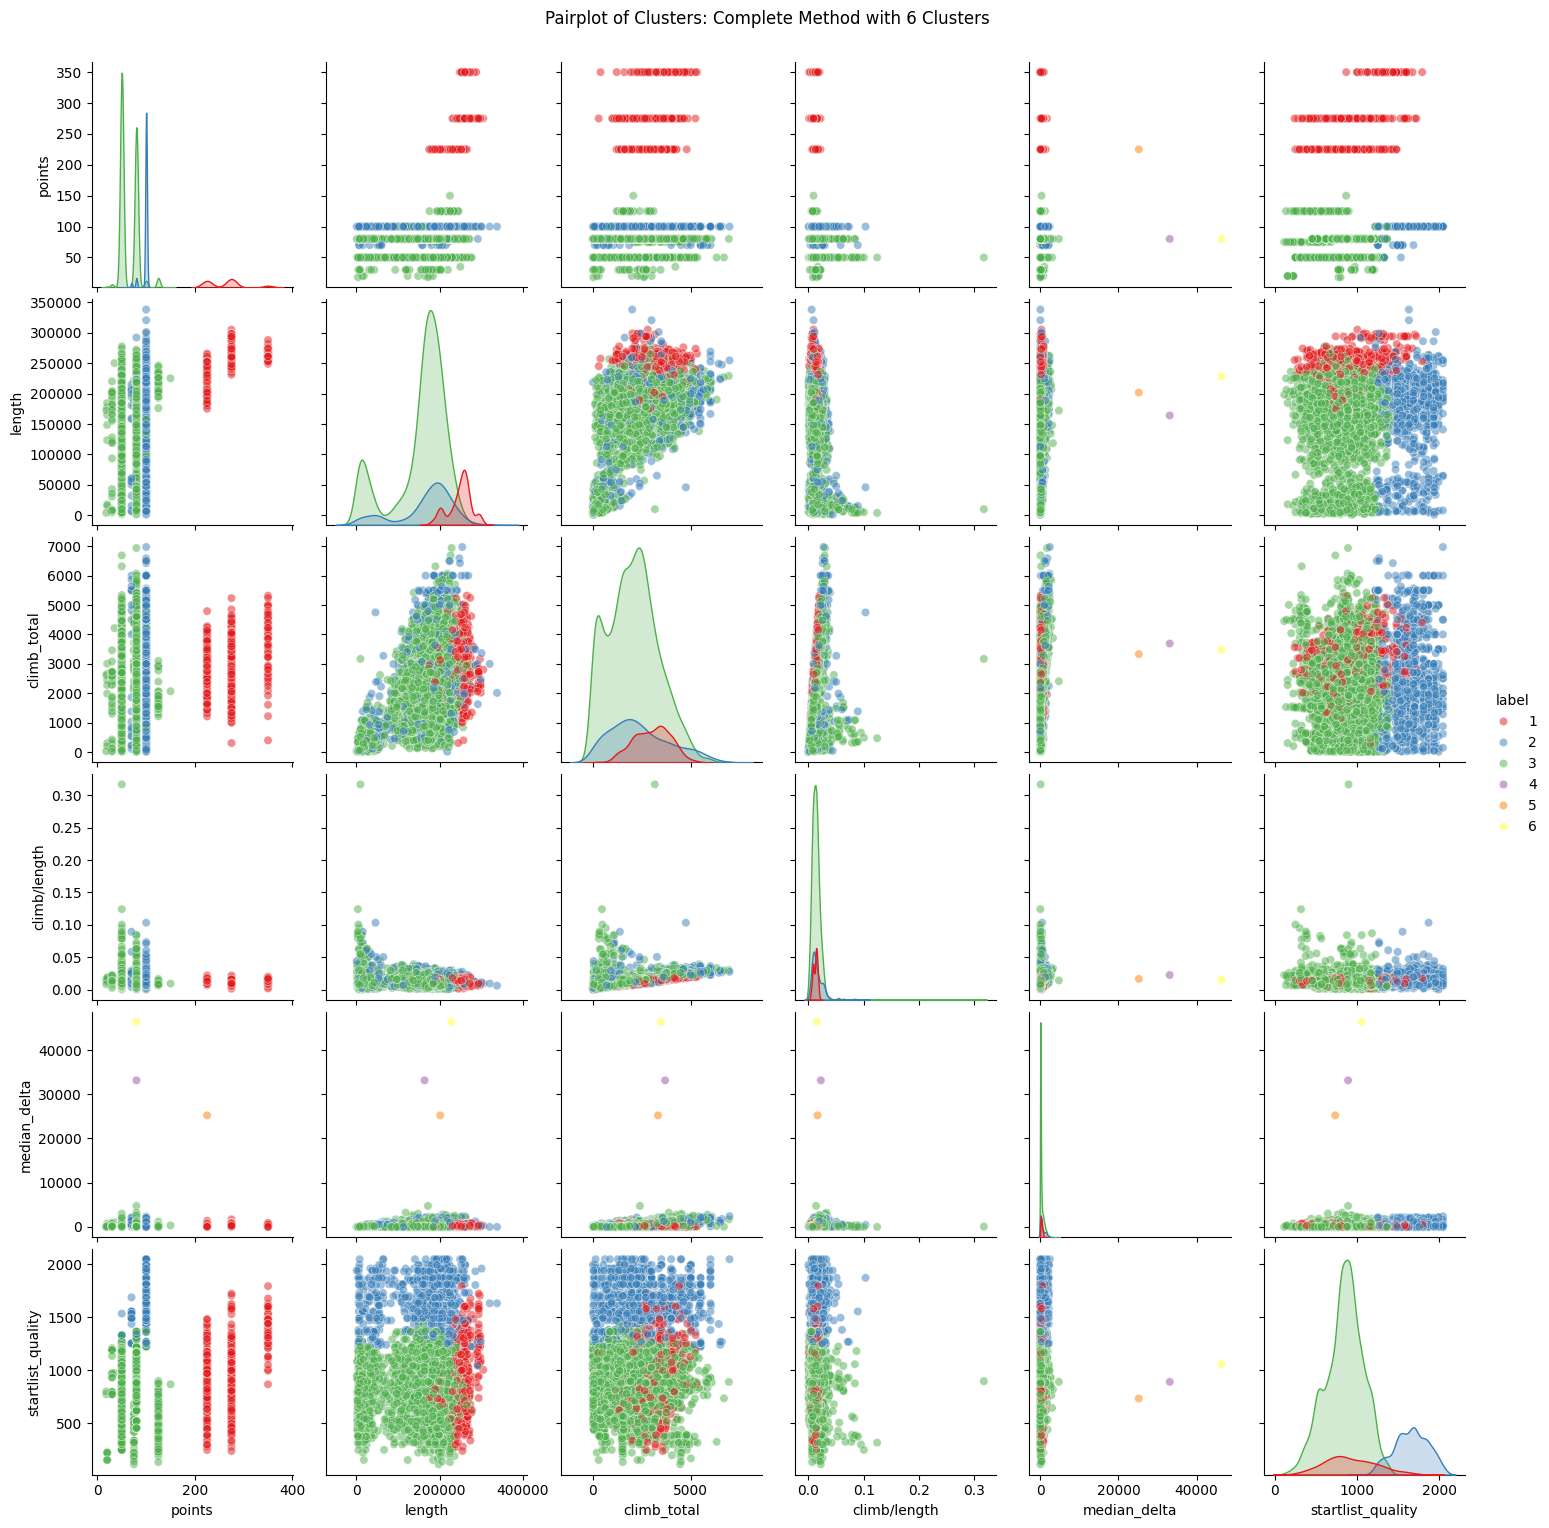

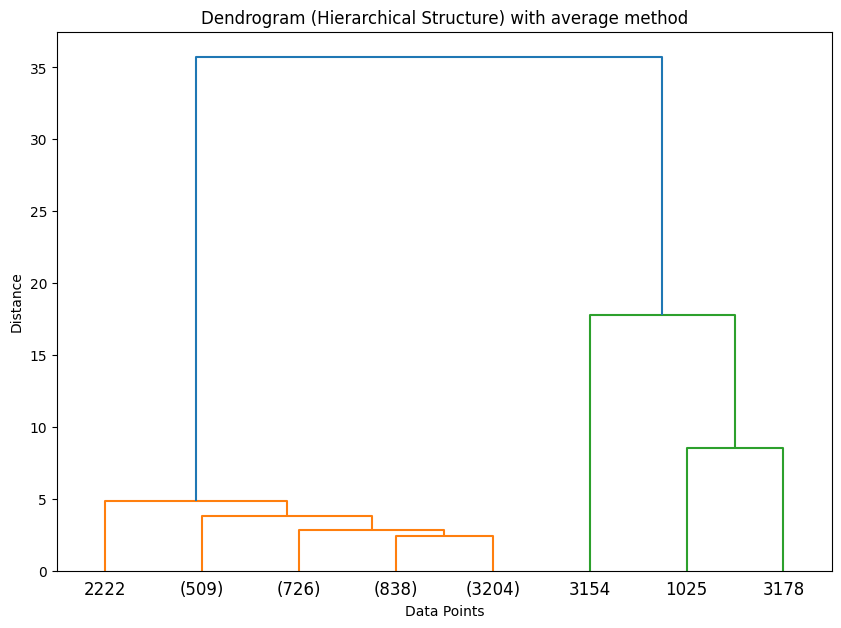

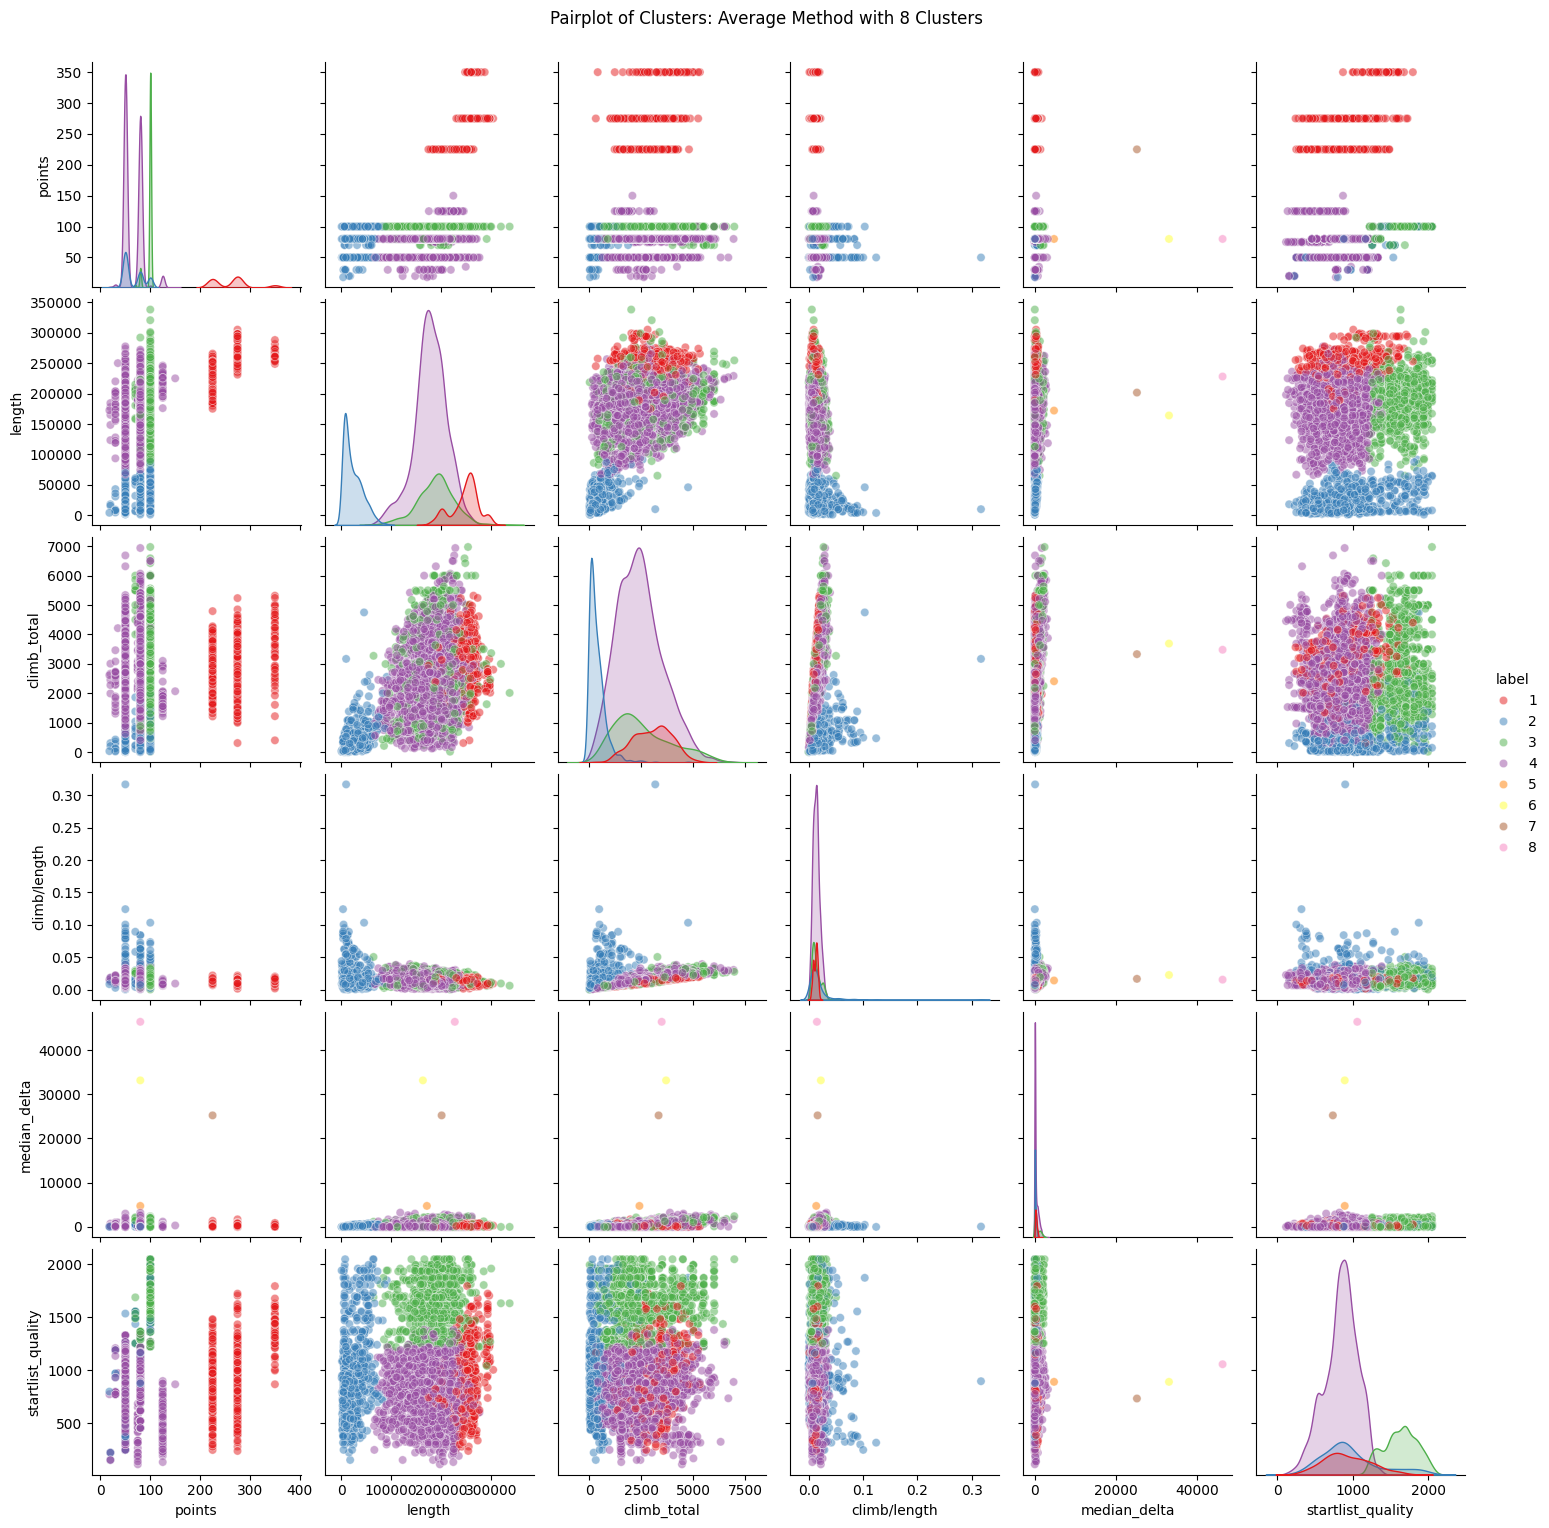

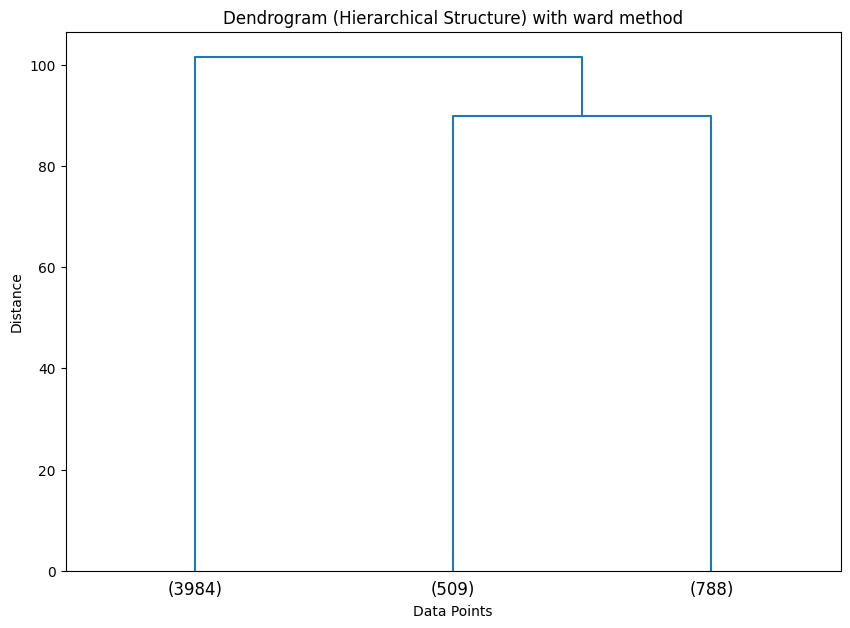

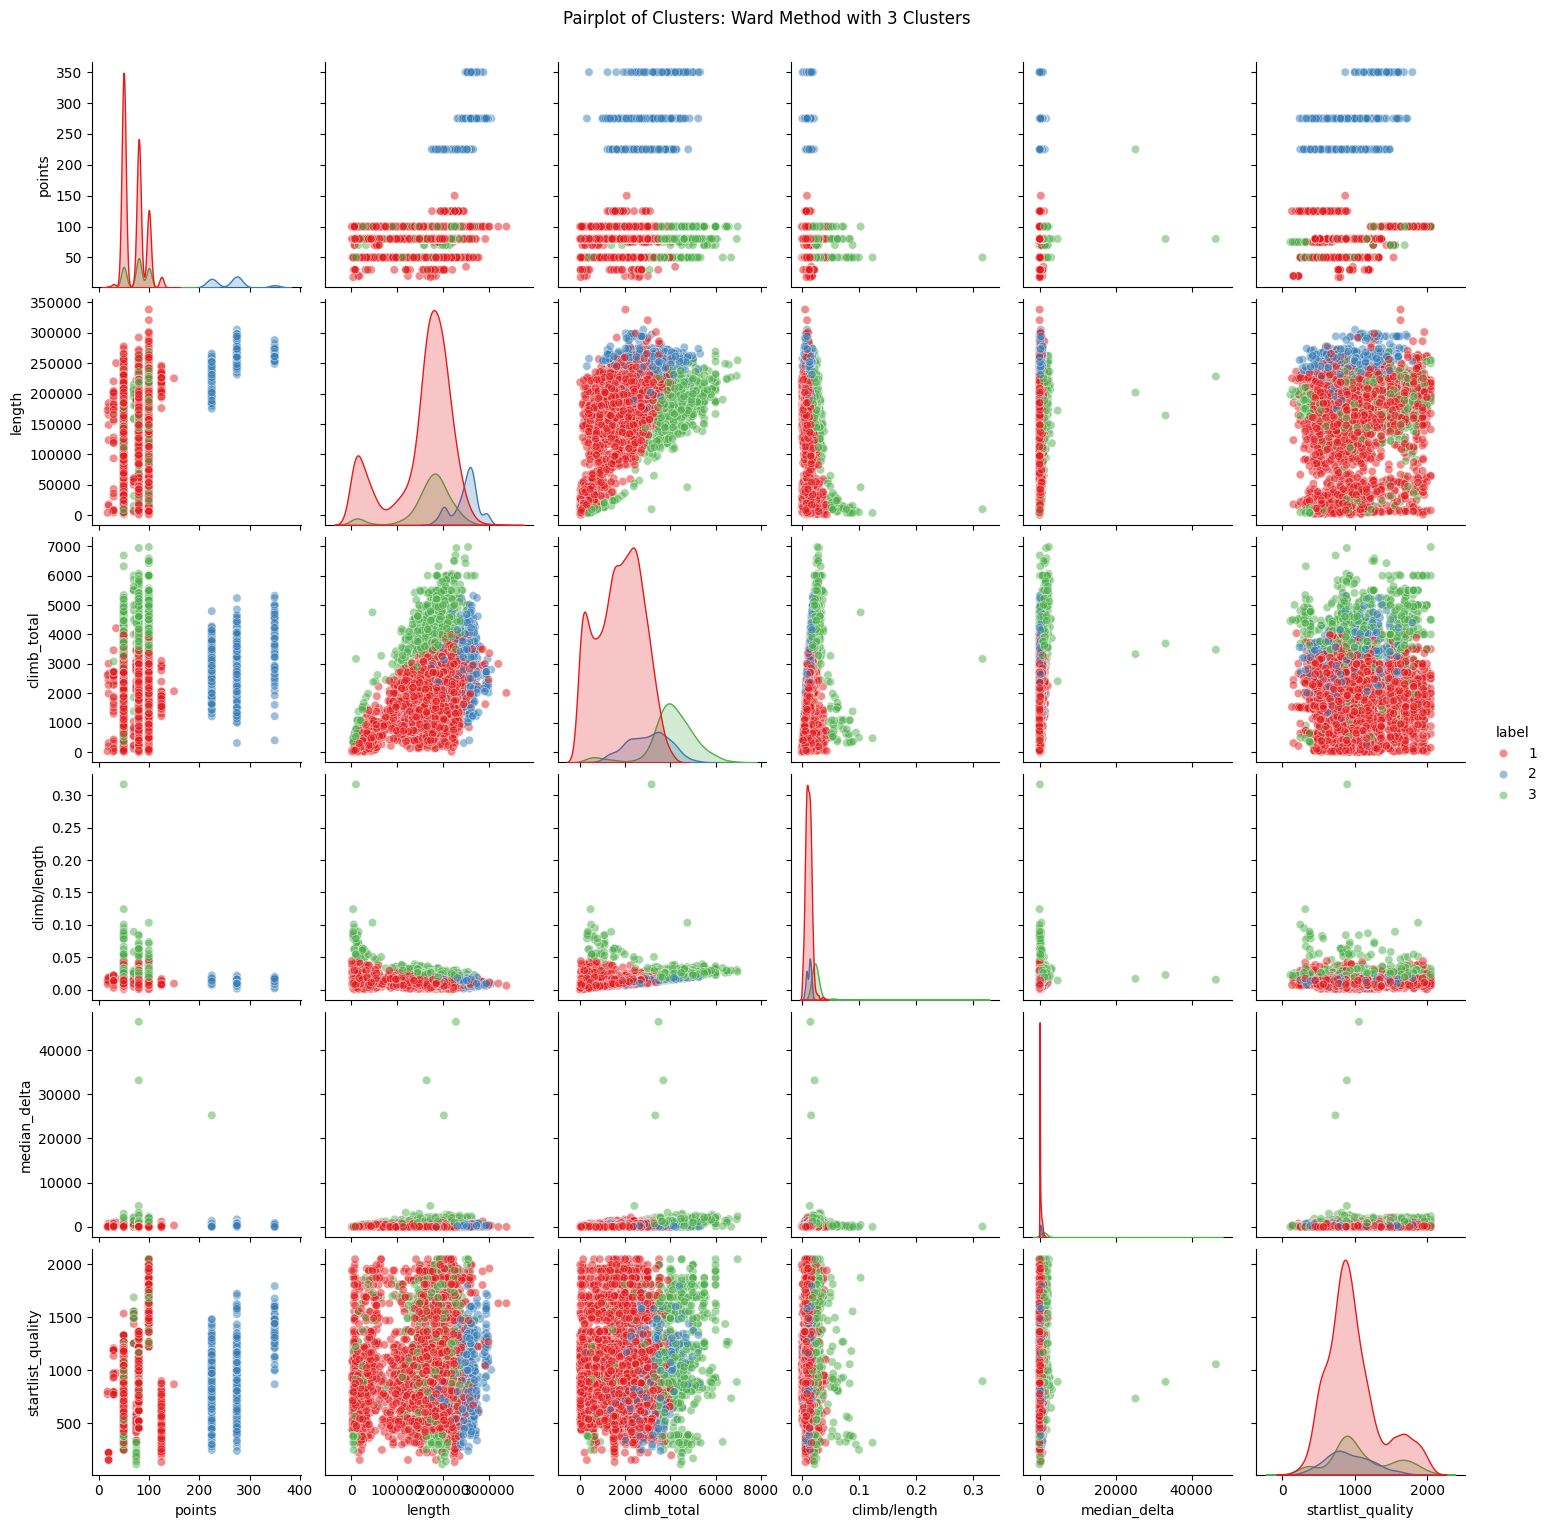

In [191]:
best_results = [
    {
        "method": "complete",
        "cluster_sizes": [509, 892, 3877, 1, 1, 1],
        "n_clusters": 6,
        "silhouette_score": 0.424629,
        "coph_corr": 0.855532,
        "features": ["points", "length", "median_delta", "startlist_quality"]
    },
    {
        "method": "average",
        "cluster_sizes": [509, 726, 838, 3204, 1, 1, 1, 1],
        "n_clusters": 8,
        "silhouette_score": 0.457533,
        "coph_corr": 0.902532,
        "features": ["points", "length", "median_delta", "startlist_quality"]
    },
    {
       "method": "ward",
        "cluster_sizes": [3984, 509, 788],
        "n_clusters": 3,
        "silhouette_score": 0.510791,
        "coph_corr": 0.528452,
        "features": ["points", "climb_total", "climb/length", "median_delta"]
    }
]

for result in best_results:
    show_dendogram(std_numeric_races[result["features"]], 
                   result["n_clusters"], result["method"], 'euclidean')
    labels = retrieve_clusters_and_score(std_numeric_races[result["features"]], 
                   result["n_clusters"], result["method"], 'euclidean')['clusters']
    to_visualize = races_working_dataset.copy()
    to_visualize.loc[:, 'label'] = labels
    # Generate pairplot with a title
    pairplot = sbn.pairplot(data=to_visualize, hue='label', palette='Set1', plot_kws={'alpha': 0.5})
    pairplot.figure.suptitle(f"Pairplot of Clusters: {result['method'].capitalize()} Method "
                      f"with {result['n_clusters']} Clusters", 
                      y=1.02)  # Adjust title position slightly above the plot
    plt.show()
    plt.close()

In this case, we will analyze the Ward method, which appears to be the better choice due to its balanced cluster sizes and relatively high silhouette score. This combination ensures interpretable and meaningful clustering results while maintaining good cluster cohesion and separation.

In [192]:
result_to_analyze = {
    "method": "ward",
    "cluster_sizes": [3984, 509, 788],
    "n_clusters": 3,
    "silhouette_score": 0.510791,
    "coph_corr": 0.528452,
    "features": ["points", "climb_total", "climb/length", "median_delta"]
}

### Analyzing Feature Distribution Segmented by Cluster

With this conditional boxplot, we analyze how the distribution of various features changes when segmented by the cluster labels. This visualization helps us understand the specific characteristics of each cluster, highlighting differences in feature ranges, medians, and variability.

In [1]:
from clustering_utility import clusters_conditional_box_plot

labels = retrieve_clusters_and_score(std_numeric_races[result_to_analyze["features"]], 
result_to_analyze["n_clusters"], result_to_analyze["method"], 'euclidean')['clusters']
to_visualize = races_working_dataset.copy()
to_visualize.loc[:, 'label'] = labels

clusters_conditional_box_plot(to_visualize, 'label')


ModuleNotFoundError: No module named 'clustering_utility'

# Placements


In [195]:
stats_on_missing_values(placements)

,Feature,Null_counter,Perc_of_null_(%)
0,position,0,0.0
1,cyclist,0,0.0
2,cyclist_age,0,0.0
3,cyclist_team,159161,27.0
4,delta,0,0.0
5,date,0,0.0
6,_url,0,0.0
7,year,0,0.0


## Correlation matrix

In [225]:
display(placements.columns)

placements_numeric_columns = ['position', 'cyclist_age', 'delta', 'year']

Index(['position', 'cyclist', 'cyclist_age', 'cyclist_team', 'delta', 'date',
       '_url', 'year'],
      dtype='object')

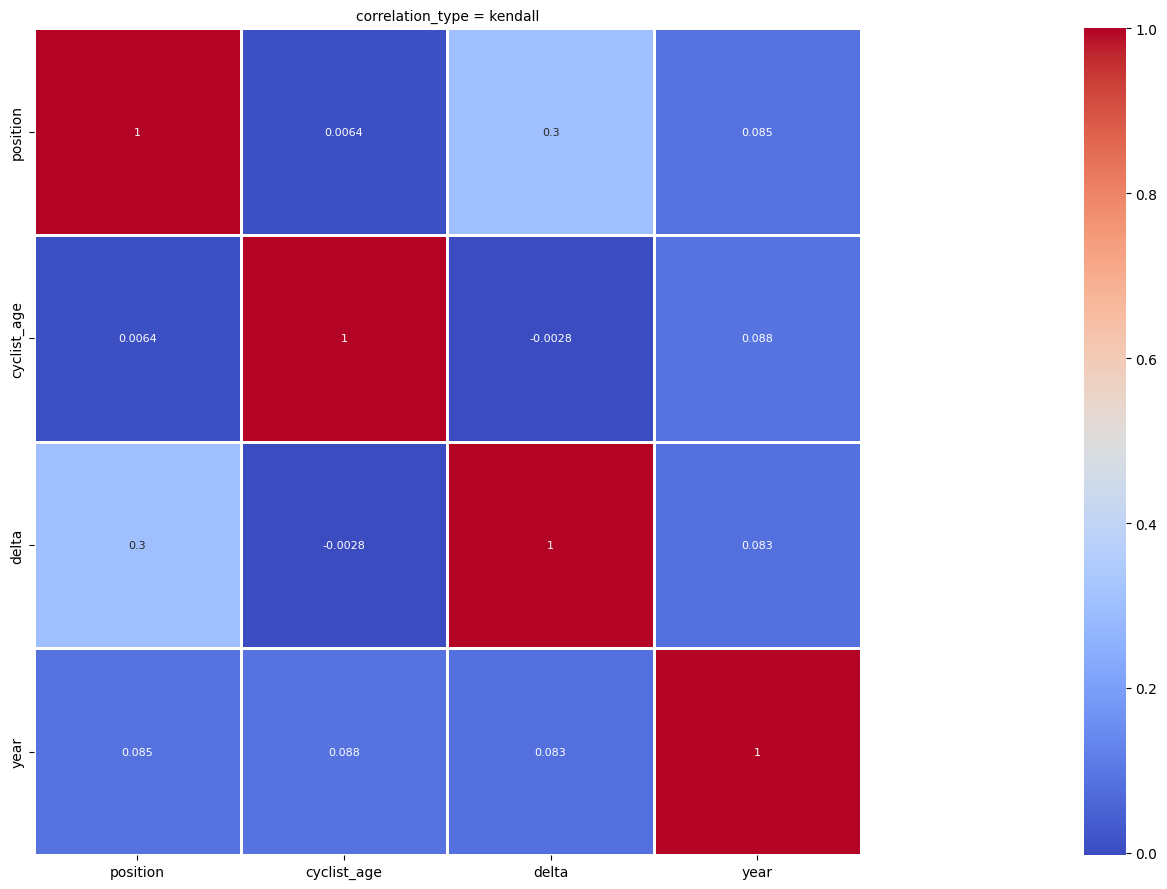

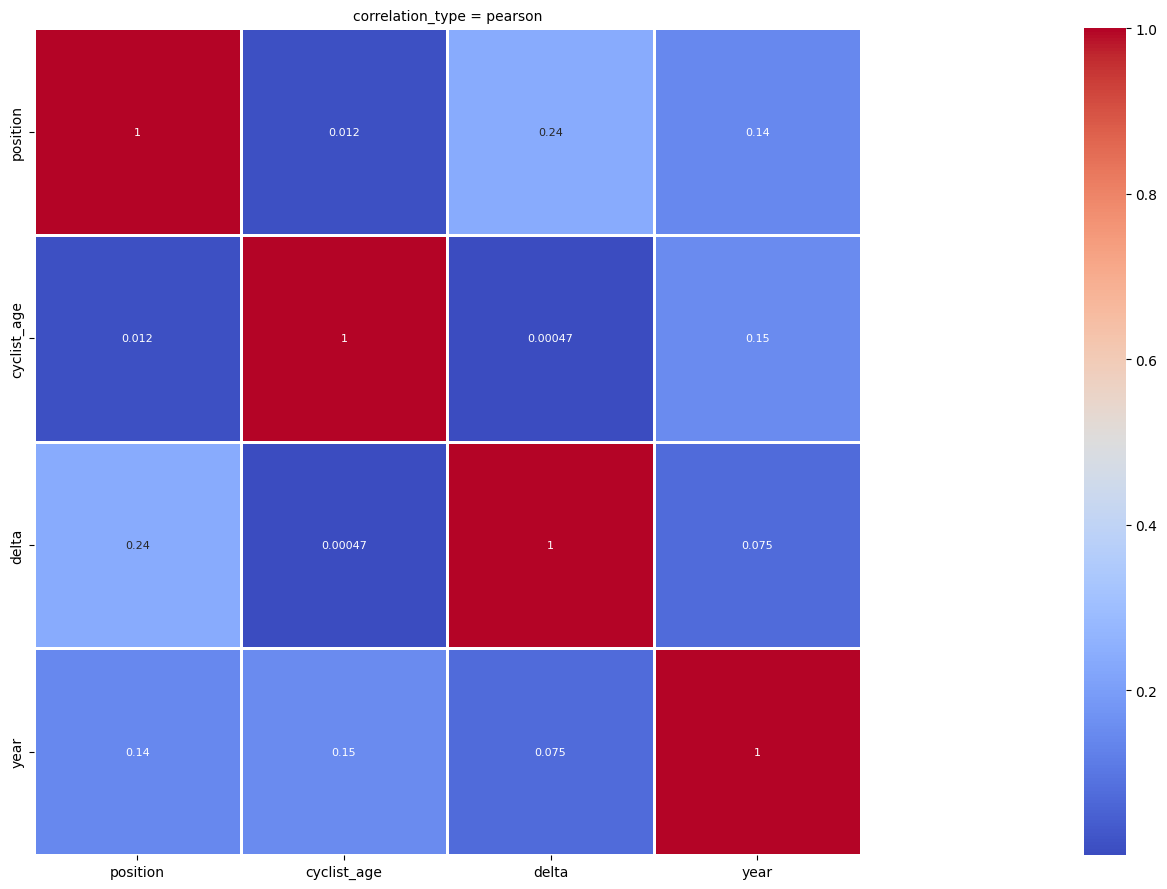

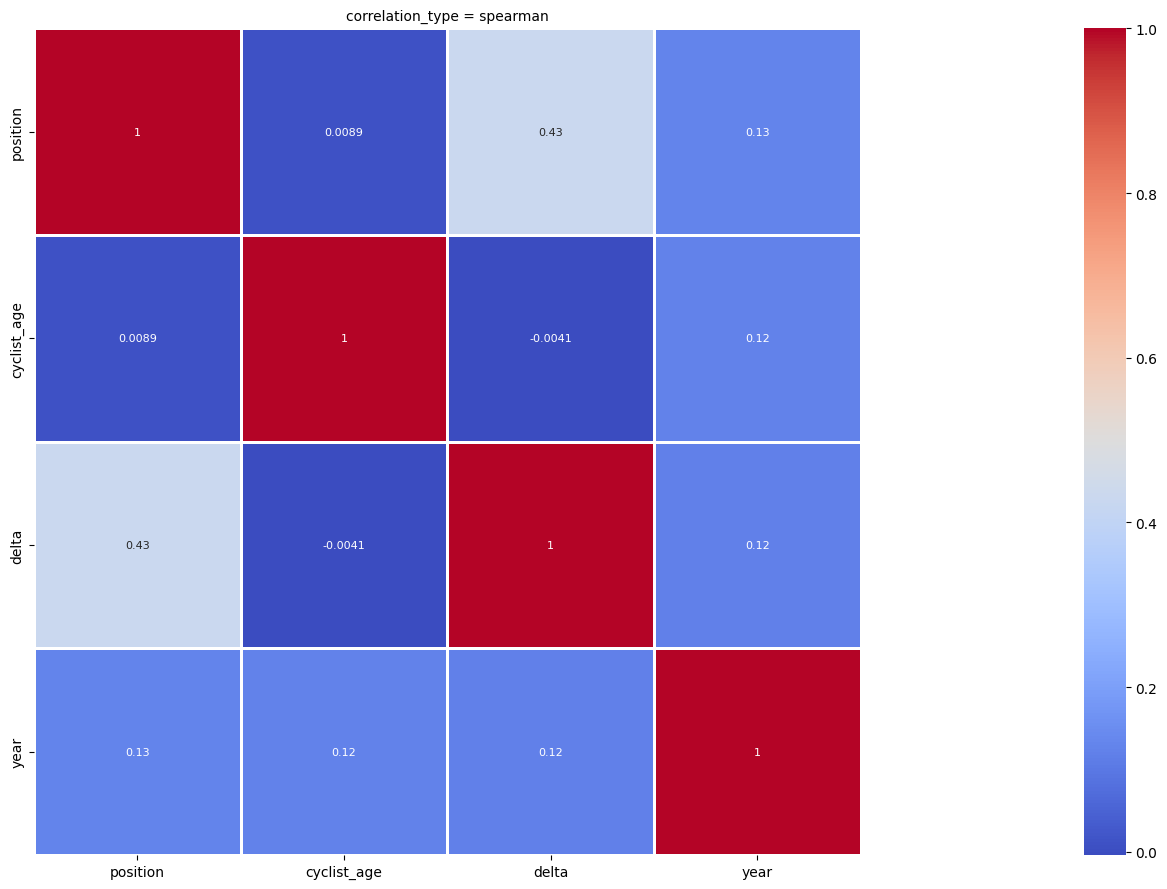

In [226]:
for method in ['kendall', 'pearson', 'spearman']:
    show_heatmap(placements, columns = placements_numeric_columns, correlation_method = method)

In [227]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columns = placements_numeric_columns
placements_working_dataset = placements[columns]
# Fit the scaler only once per subset
scaler.fit(placements_working_dataset)
std_numeric_placements = pd.DataFrame(scaler.transform(placements_working_dataset), columns=columns)
display(std_numeric_placements)

,position,cyclist_age,delta,year
0,-1.533334,-1.163424,-0.424558,-3.151069
1,-1.512675,-0.644689,-0.424558,-3.151069
2,-1.492015,-1.422791,-0.402884,-3.151069
3,-1.471356,-1.163424,-0.392047,-3.151069
4,-1.450697,-1.422791,-0.392047,-3.151069
...,...,...,...,...
589860,0.491292,-1.422791,0.253251,1.379530
589861,0.511952,-1.422791,0.265073,1.379530
589862,0.532611,-0.904056,0.430585,1.379530
589863,0.553271,-1.422791,0.467037,1.379530


In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage

simple_result = []
for method in ['ward', 'complete', 'average', 'single']:
    cluster_score_5 = retrieve_clusters_and_score(std_numeric_placements, 5, method, 'euclidean')
    cluster_score_6 = retrieve_clusters_and_score(std_numeric_placements, 6, method, 'euclidean')
    cluster_score_7 = retrieve_clusters_and_score(std_numeric_placements, 7, method, 'euclidean')
    simple_result.append(cluster_score_5)
    simple_result.append(cluster_score_6)
    simple_result.append(cluster_score_7)
display(pd.DataFrame(simple_result))

MemoryError: Unable to allocate 1.27 TiB for an array with shape (173970064180,) and data type float64

Due to the large size of the dataset, the hierarchical clustering method fails as it cannot handle the computational and memory demands required to calculate and store the full distance matrix. To address this issue, we need to perform sampling by selecting a manageable subset of the data. This approach will allow us to gain insights into the clustering structure without overloading computational resources.